# HeatMap Hackathon 2026 - Burn Care Access Analysis
### National Injury Resource Database (NIRD) · BData / American Burn Association

---

**Primary Use Case:** Advancing Equitable Access to Burn Care  

**Mechanisms:** Referral gaps and telemedicine are analyzed only as mechanisms that drive *inequity*

**Primary Dataset:** NIRD Database (2023) - 635 hospitals across 50 states  

**Sources:** NIRD Database (2023); U.S. Census Bureau County Population Centroids (2020); CDC/ATSDR SVI (2022); USDA RUCC (2023); Ivanko et al. J Burn Care Res (2024); Lovick et al. Burns (2024); Huang et al. (2021); Murray et al. (2019). Distance analysis: Haversine great-circle method; Census batch geocoding + manual verification for 18 hospitals. Team 13 analysis.

---

**Team 13**
1. Emmanuel Fle Chea
2. Josh Spitzer-Resnick
3. Shreya Pramanik
4. Feifei Li
5. Lance Killian McDonald

---

### Analysis Roadmap
| # | Analysis | Use Case |
|---|---|---|
| 1 | Data Loading & Cleaning | All |
| 2 | Burn Center Density by State | Equity |
| 3 | Burn Bed Capacity per 100k Residents | Equity |
| 4 | Referral Gap - Trauma Centers w/o Burn Capability | Referral Networks |
| 5 | Telemedicine Opportunity Score | Telemedicine |
| 6 | Pediatric vs. Adult Access Gap | Equity |
| 7 | ABA Verification Rate by State | Equity / Quality |
| 8 | Equity Quadrant: Access vs. Quality | Equity |
| 9 | Composite Vulnerability Index | Equity |
| 10 | Top Telemedicine Hub Candidates (Hospital Level) | Telemedicine |
| 11 | Executive Dashboard | All |
| 12 | Export Summary Excel Workbook | All |

---
## Imports & Global Configuration

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import seaborn as sns
import warnings, os
import openpyxl, statistics
from collections import defaultdict
import io
import os
import requests
import folium
import math

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 14,
    'axes.labelsize'     : 11,
    'figure.dpi'         : 130,
    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',
})

# --- Colour palette -------------------------------------
C = dict(
    burn    = '#D62728',
    trauma  = '#1F77B4',
    aba     = '#FF7F0E',
    peds    = '#2CA02C',
    gap     = '#9467BD',
    tele    = '#17BECF',
    neutral = '#7F7F7F',
    bg      = '#F8F8F8',
)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2022 US Census state populations (thousands) ---------------------
STATE_POP = {
    'AL':5074,'AK':733, 'AZ':7359,'AR':3046,'CA':39030,'CO':5840,'CT':3626,
    'DE':1018,'FL':22611,'GA':10912,'HI':1441,'ID':1939,'IL':12582,'IN':6833,
    'IA':3200,'KS':2937,'KY':4512,'LA':4590,'ME':1385,'MD':6165,'MA':6982,
    'MI':10034,'MN':5717,'MS':2961,'MO':6178,'MT':1122,'NE':1967,'NV':3178,
    'NH':1395,'NJ':9261,'NM':2113,'NY':19678,'NC':10699,'ND':779,'OH':11756,
    'OK':4020,'OR':4240,'PA':12972,'RI':1094,'SC':5282,'SD':909,'TN':7051,
    'TX':30030,'UT':3381,'VT':647,'VA':8683,'WA':7785,'WV':1775,'WI':5895,
    'WY':581,'DC':671
}

print(' Setup complete.')

 Setup complete.


---
## Load & Clean NIRD Data

In [7]:
df = pd.read_excel("/NIRD 20230130 Database_Hackathon.xlsx",sheet_name='Data Table NIRD 20230130')

# --- Normalise binary indicator columns -----------------------------------
binary_cols = [
    'BURN_ADULT','BURN_PEDS','TRAUMA_ADULT','TRAUMA_PEDS',
    'ADULT_TRAUMA_L1','ADULT_TRAUMA_L2','PEDS_TRAUMA_L1','PEDS_TRAUMA_L2',
    'TC_STATE_DESIGNATED','BC_STATE_DESIGNATED'
]
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['ABA_VERIFIED'] = (df['ABA_VERIFIED'] == 'Yes').astype(int)
df['ACS_VERIFIED'] = (df['ACS_VERIFIED'] == 'Yes').astype(int)

# --- Composite flags ---------------------------------------------------------
df['HAS_BURN']       = ((df['BURN_ADULT']      == 1) | (df['BURN_PEDS']      == 1)).astype(int)
df['HAS_TRAUMA']     = ((df['TRAUMA_ADULT']    == 1) | (df['TRAUMA_PEDS']    == 1)).astype(int)
df['TRAUMA_NO_BURN'] = ((df['HAS_TRAUMA']      == 1) & (df['HAS_BURN']       == 0)).astype(int)
df['L1_NO_BURN']     = ((df['ADULT_TRAUMA_L1'] == 1) & (df['BURN_ADULT']     == 0)).astype(int)
df['L2_NO_BURN']     = ((df['ADULT_TRAUMA_L2'] == 1) & (df['BURN_ADULT']     == 0)).astype(int)
df['STATE_POP_K']    = df['STATE'].map(STATE_POP)

print(f'Hospitals loaded  : {len(df)}')
print(f'States covered    : {df["STATE"].nunique()}')
print(f'Adult burn centers: {df["BURN_ADULT"].sum()}')
print(f'ABA-verified      : {df["ABA_VERIFIED"].sum()}')
print(f'L1+L2 trauma      : {(df["ADULT_TRAUMA_L1"] | df["ADULT_TRAUMA_L2"]).sum()}')
print(f'Trauma w/o burn   : {df["TRAUMA_NO_BURN"].sum()}')
df.head(3)

Hospitals loaded  : 635
States covered    : 50
Adult burn centers: 120
ABA-verified      : 74
L1+L2 trauma      : 565
Trauma w/o burn   : 498


,STATE_FULL,STATE,COUNTY,ADDRESS,CITY,ZIP_CODE,AHA_ID,HOSPITAL_NAME,TOTAL_BEDS,BURN_BEDS,...,ABA_VERIFIED,TC_STATE_DESIGNATED,BC_STATE_DESIGNATED,PHONE,HAS_BURN,HAS_TRAUMA,TRAUMA_NO_BURN,L1_NO_BURN,L2_NO_BURN,STATE_POP_K
0,Alaska,AK,Anchorage,4315 Diplomacy Dr,Anchorage,99508,6940010.0,Alaska Native Medical Center,173,NaN,...,0,0,0,(907) 563-2662,0,1,1,0,1,733
1,Alaska,AK,Anchorage,3200 Providence Dr,Anchorage,99508,6940020.0,Providence Alaska Medical Center/Children's Ho...,401,NaN,...,0,0,0,(907) 562-2211,0,1,1,0,1,733
2,Alabama,AL,Houston,1108 Ross Clark Cir,Dothan,36301,6530373.0,Southeast Alabama Medical Center,387,NaN,...,0,0,0,(334) 793-8111,0,1,1,0,1,5074


---
## State - Level Aggregation

In [8]:
state_df = df.groupby('STATE').agg(
    total_hospitals   = ('AHA_ID',         'count'),
    burn_centers      = ('BURN_ADULT',      'sum'),
    burn_peds_centers = ('BURN_PEDS',       'sum'),
    aba_verified      = ('ABA_VERIFIED',    'sum'),
    bc_state_desig    = ('BC_STATE_DESIGNATED','sum'),
    l1_trauma         = ('ADULT_TRAUMA_L1', 'sum'),
    l2_trauma         = ('ADULT_TRAUMA_L2', 'sum'),
    trauma_no_burn    = ('TRAUMA_NO_BURN',  'sum'),
    l1_no_burn        = ('L1_NO_BURN',      'sum'),
    l2_no_burn        = ('L2_NO_BURN',      'sum'),
    total_burn_beds   = ('BURN_BEDS',       'sum'),
    total_beds        = ('TOTAL_BEDS',      'sum'),
).reset_index()

# --- Load SVI (county-level) -----------------------------------------
svi = pd.read_csv('/SVI_2022_US_county.csv', dtype={'FIPS': str})

svi_small = svi[['FIPS','EP_NOVEH','EP_POV150','EP_LIMENG','EP_DISABL','EP_MINRTY']].copy()

svi_small['STATE_FIPS'] = svi_small['FIPS'].str[:2]

# Drop FIPS so it doesn't get averaged
svi_small = svi_small.drop(columns=['FIPS'])

# Now group safely
svi_state = svi_small.groupby('STATE_FIPS').mean().reset_index()

# Map STATE_FIPS -> state abbreviation

fips_to_state = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT','10':'DE','11':'DC',
    '12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN','19':'IA','20':'KS','21':'KY',
    '22':'LA','23':'ME','24':'MD','25':'MA','26':'MI','27':'MN','28':'MS','29':'MO','30':'MT',
    '31':'NE','32':'NV','33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND','39':'OH',
    '40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD','47':'TN','48':'TX','49':'UT',
    '50':'VT','51':'VA','53':'WA','54':'WV','55':'WI','56':'WY','72':'PR' # Added PR
}

# Create a Master DataFrame of all possible states
master_states = pd.DataFrame(list(fips_to_state.items()), columns=['STATE_FIPS', 'STATE'])
# Convert FIPS column to string and pad with zero before mapping

svi_state['STATE'] = svi_state['STATE_FIPS'].map(fips_to_state)

# Merge with the existing state_df
state_df = state_df.merge(svi_state, on='STATE', how='left')

state_df['pop_k']         = state_df['STATE'].map(STATE_POP)
state_df['pop_M']         = state_df['pop_k'] / 1000
state_df['burn_per_M']    = (state_df['burn_centers']    / state_df['pop_M']).round(2)
state_df['beds_per_100k'] = (state_df['total_burn_beds'] / state_df['pop_k'] * 100).round(3)
state_df['pct_aba']       = (
    state_df['aba_verified'] /
    state_df['burn_centers'].replace(0, np.nan) * 100
).fillna(0).round(1)

no_burn_states = state_df[state_df['burn_centers'] == 0]['STATE'].tolist()
print(f'States with ZERO adult burn centers: {no_burn_states}')
state_df.sort_values('burn_per_M', ascending=False).head(10)

States with ZERO adult burn centers: ['AK', 'DE', 'MS', 'MT', 'ND', 'NH', 'SD']


,STATE,total_hospitals,burn_centers,burn_peds_centers,aba_verified,bc_state_desig,l1_trauma,l2_trauma,trauma_no_burn,l1_no_burn,...,EP_NOVEH,EP_POV150,EP_LIMENG,EP_DISABL,EP_MINRTY,pop_k,pop_M,burn_per_M,beds_per_100k,pct_aba
46,VT,1,1,0,0,0,1,0,0,0,...,5.835714,17.907143,0.307143,15.600000,7.464286,647,0.647,1.55,1.391,0.0
7,DC,4,1,1,1,0,3,0,2,2,...,35.700000,20.600000,2.100000,11.000000,63.700000,671,0.671,1.49,6.110,100.0
39,RI,1,1,1,1,0,1,0,0,0,...,7.040000,14.180000,2.080000,12.340000,18.400000,1094,1.094,0.91,0.000,100.0
18,LA,8,4,1,2,0,2,5,5,0,...,8.015625,32.439062,0.978125,17.318750,39.471875,4590,4.590,0.87,1.024,50.0
24,MO,20,5,5,1,0,9,8,13,4,...,5.953913,26.005217,0.500000,17.630435,11.355652,6178,6.178,0.81,1.505,20.0
21,ME,2,1,0,0,0,1,1,1,0,...,6.762500,20.825000,0.350000,17.168750,7.575000,1385,1.385,0.72,0.433,0.0
11,HI,3,1,1,0,0,1,1,2,1,...,6.540000,17.500000,2.620000,13.960000,73.760000,1441,1.441,0.69,0.486,0.0
16,KS,5,2,2,2,0,3,2,3,1,...,4.316190,21.094286,1.719048,15.637143,17.326667,2937,2.937,0.68,0.953,100.0
33,NV,3,2,2,1,0,1,2,1,0,...,5.629412,20.376471,2.029412,17.152941,31.929412,3178,3.178,0.63,0.975,50.0
49,WV,5,1,0,0,0,2,3,4,2,...,7.876364,28.056364,0.243636,20.712727,7.363636,1775,1.775,0.56,0.225,0.0


---
## Figure 1 - Burn Center Density by State

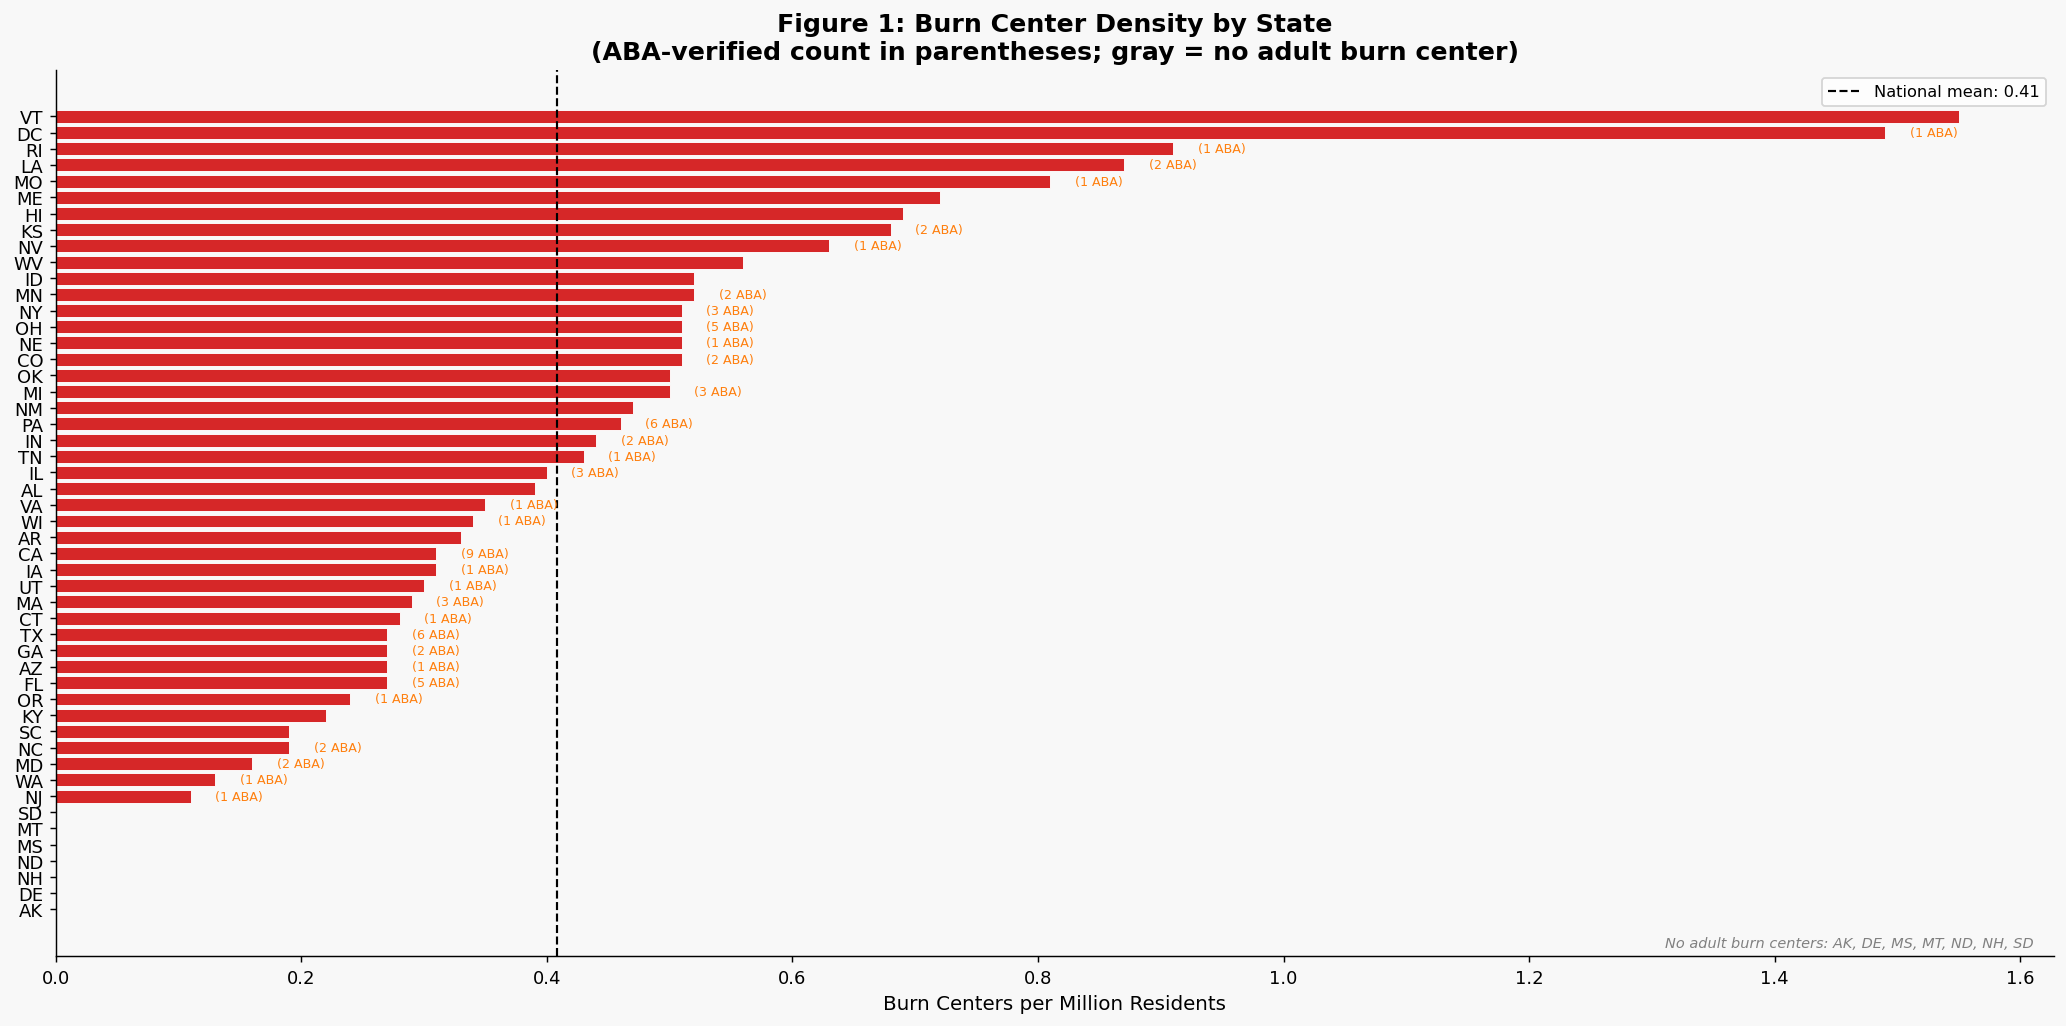

In [9]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

plot_df = state_df.sort_values('burn_per_M', ascending=True)
colors  = [C['burn'] if v > 0 else '#CCCCCC' for v in plot_df['burn_per_M']]
ax.barh(plot_df['STATE'], plot_df['burn_per_M'],
        color=colors, edgecolor='white', linewidth=0.5)

for i, row in enumerate(plot_df.itertuples()):
    if row.aba_verified > 0:
        ax.text(row.burn_per_M + 0.02, i,
                f'({row.aba_verified} ABA)', va='center',
                fontsize=7, color=C['aba'])

mean_val = plot_df['burn_per_M'].mean()
ax.axvline(mean_val, color='black', ls='--', lw=1.2,
           label=f'National mean: {mean_val:.2f}')
ax.set_xlabel('Burn Centers per Million Residents')
ax.set_title(
    'Figure 1: Burn Center Density by State\n'
    '(ABA-verified count in parentheses; gray = no adult burn center)',
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.text(0.99, 0.01,
        f'No adult burn centers: {", ".join(no_burn_states)}',
        transform=ax.transAxes, ha='right', fontsize=8,
        color='gray', style='italic')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_burn_density_by_state.png')
plt.show()

In [10]:
# 1. Pre-plotting Fix: Ensure NaNs are zeros so they map to the "Reds" scale
state_df['burn_per_M'] = state_df['burn_per_M'].fillna(0)

# Create interactive choropleth map
fig1i = px.choropleth(
    state_df,
    locations='STATE',
    locationmode='USA-states',
    color='burn_per_M',
    scope='usa',
    color_continuous_scale='Reds',
    # Fix A: Force the color scale to start at 0 to distinguish "Zero" from "No Data"
    range_color=[0, state_df['burn_per_M'].max()],
    title='Fig1i :Burn Center Density by State (Centers per Million Residents)',
    hover_data={
        'STATE': False,
        'burn_per_M': ':.2f', # Format for readability
        'burn_centers': True,
        'aba_verified': True,
        'pop_M': ':.2f'
    },
    labels={
        'burn_per_M': 'Centers per 1M',
        'burn_centers': 'Total Burn Centers',
        'aba_verified': 'ABA Verified',
        'pop_M': 'Population (Millions)'
    }
)

# Optimize layout for visual clarity
fig1i.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    # Fix B: Define behavior for the geographic background
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='lightblue',
        showlakes=True,
        showland=True,
        landcolor='lightgray' # Missing states will now be gray instead of blue
    )
)

fig1i.show()
fig1i.write_html("Figure_1i.html")

---
## Figure 2 - Burn Bed Capacity per 100k Residents

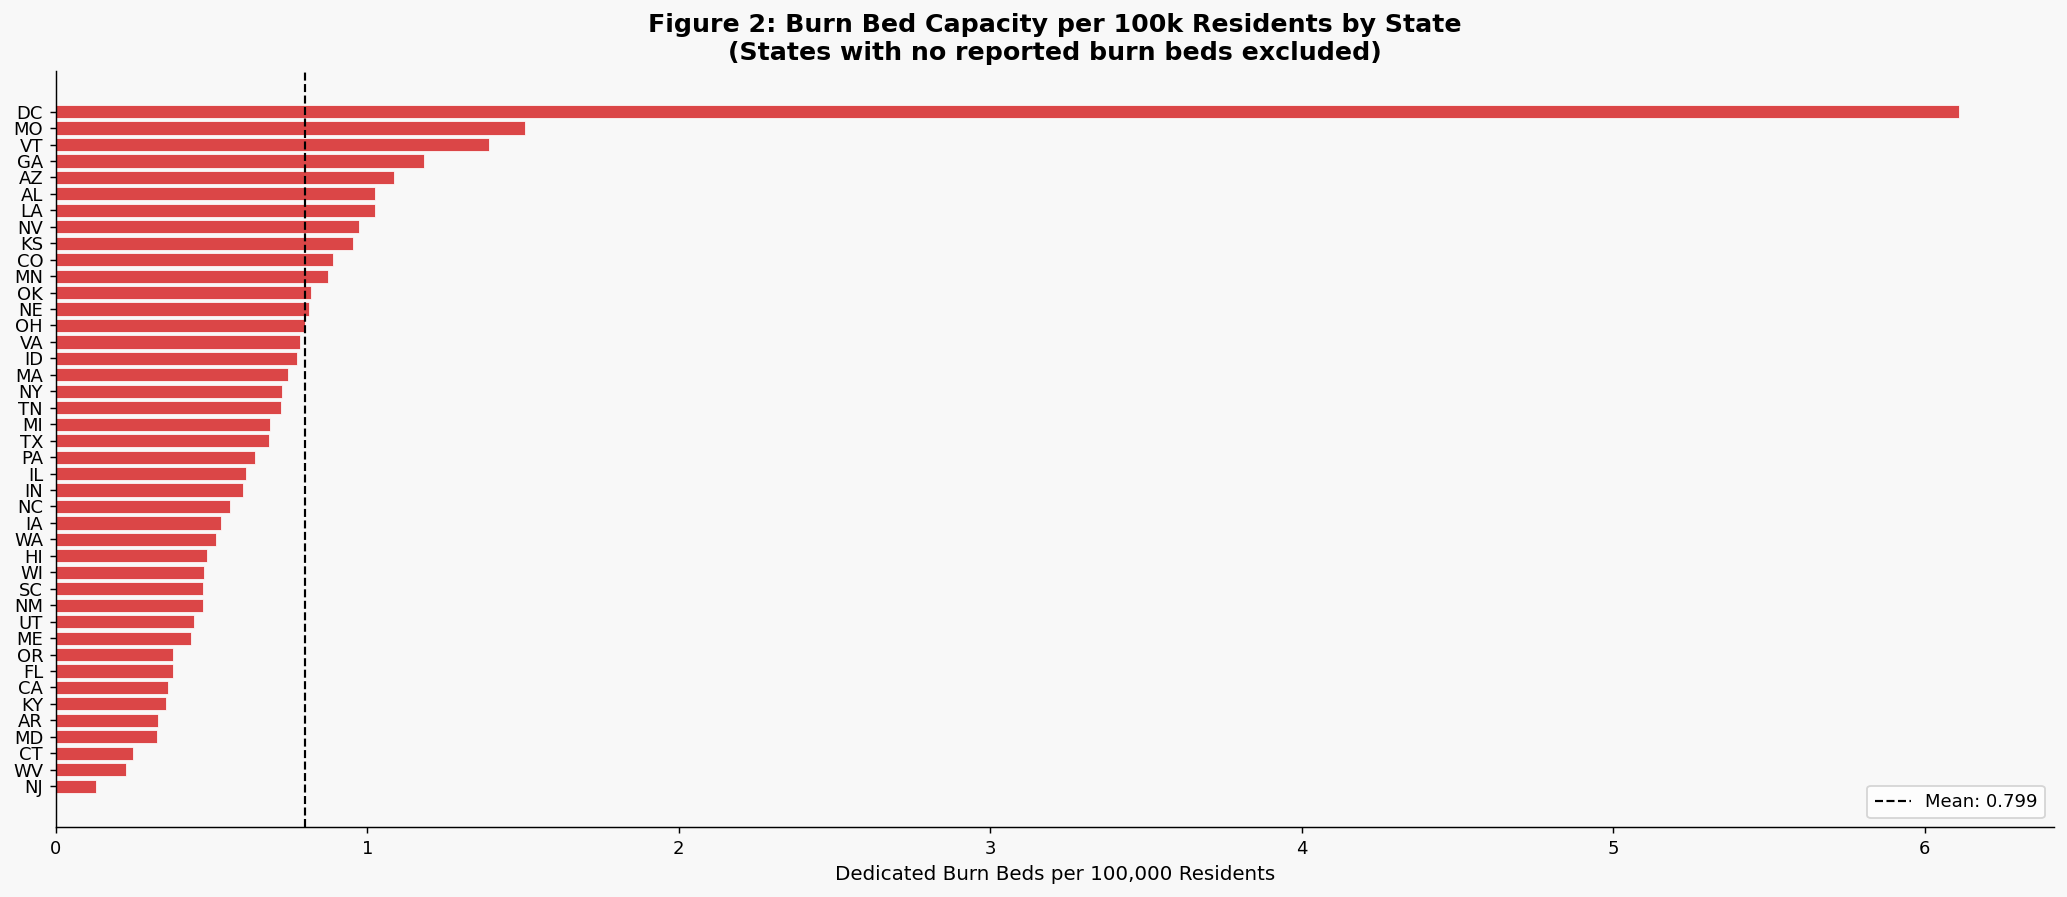

In [11]:
plot_df2 = state_df[state_df['beds_per_100k'] > 0].sort_values('beds_per_100k', ascending=True)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

ax.barh(plot_df2['STATE'], plot_df2['beds_per_100k'],
        color=C['burn'], edgecolor='white', linewidth=0.5, alpha=0.85)

mean_beds = plot_df2['beds_per_100k'].mean()
ax.axvline(mean_beds, color='black', ls='--', lw=1.2,
           label=f'Mean: {mean_beds:.3f}')
ax.set_xlabel('Dedicated Burn Beds per 100,000 Residents')
ax.set_title(
    'Figure 2: Burn Bed Capacity per 100k Residents by State\n'
    '(States with no reported burn beds excluded)',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_burnbeds_per_100k.png')
plt.show()

Interactive fig 2

In [12]:
# Sort the dataframe for sequential plotting
state_df_sorted = state_df.sort_values('beds_per_100k', ascending=False)
national_avg = state_df['beds_per_100k'].mean()

# Create interactive bar chart
fig2i = px.bar(
    state_df_sorted,
    x='STATE',
    y='beds_per_100k',
    color='beds_per_100k',
    color_continuous_scale='Blues',
    title=' Fig2i :Burn Bed Capacity by State (Beds per 100k Residents)',
    labels={
        'beds_per_100k': 'Beds per 100k',
        'STATE': 'State',
        'total_burn_beds': 'Total Burn Beds',
        'pop_M': 'Population (Millions)'
    },
    hover_data={
        'STATE': False,
        'total_burn_beds': True,
        'pop_M': True,
        'beds_per_100k': True
    }
)

# Add national average threshold line
fig2i.add_hline(
    y=national_avg,
    line_dash="dash",
    line_color="red",
    annotation_text=f"National Avg: {national_avg:.2f}",
    annotation_position="top right"
)

# Optimize layout for readability
fig2i.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='lightgrey')
)

fig2i.show()
fig2i.write_html("Figure_2i.html")

In [13]:
# Ensure zero/missing states are handled so they don't look like water
state_df['beds_per_100k'] = state_df['beds_per_100k'].fillna(0)

fig2i_map = px.choropleth(
    state_df,
    locations='STATE',
    locationmode='USA-states',
    color='beds_per_100k',
    scope='usa',
    # 'OrRd' (Orange-Red) is better for 'danger/capacity' than 'Blues'
    color_continuous_scale='OrRd',
    range_color=[0, state_df['beds_per_100k'].max()],
    title='Fig2i_map: Geographic Burn Bed Capacity (Beds per 100k)',
    hover_data={'STATE': False, 'total_burn_beds': True, 'beds_per_100k': ':.2f'}
)

# Crucial fix for the "Blue State" problem:
fig2i_map.update_geos(
    visible=False,
    resolution=50,
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="lightgrey", # Empty states will now be grey, NOT blue
    showlakes=True, lakecolor="LightBlue"
)

fig2i_map.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig2i_map.show()
fig2i_map.write_html("Figure_2i_map.html")


---
## Figure 3 - Referral Gap: Trauma Centers Without Burn Capability

L1 trauma total : 229  |  with burn: 86  |  WITHOUT burn: 143 (62.4%)
L2 trauma total : 336  |  with burn: 17  |  WITHOUT burn: 319 (94.9%)
ALL trauma      : 565  |  with burn: 67 (11.9%)  |  WITHOUT burn: 498 (88.1%)


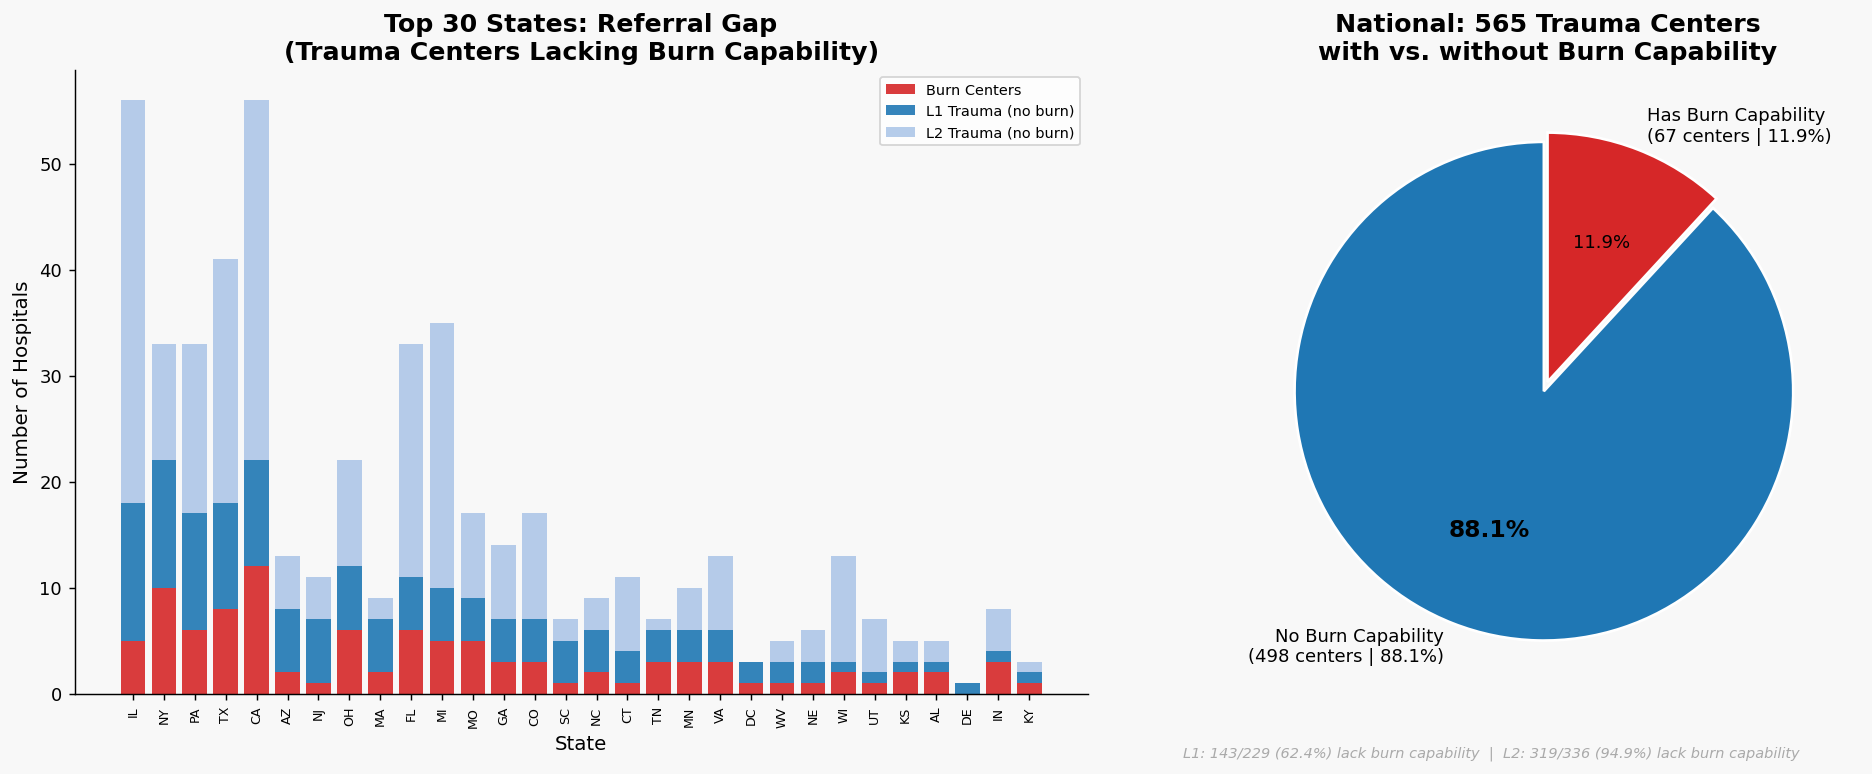

In [14]:
total_l1 = int(df['ADULT_TRAUMA_L1'].sum())
total_l2 = int(df['ADULT_TRAUMA_L2'].sum())
l1_burn  = int(df[(df['ADULT_TRAUMA_L1']==1) & (df['BURN_ADULT']==1)].shape[0])
l2_burn  = int(df[(df['ADULT_TRAUMA_L2']==1) & (df['BURN_ADULT']==1)].shape[0])
l1_no_b  = total_l1 - l1_burn
l2_no_b  = total_l2 - l2_burn
total_trauma   = total_l1 + total_l2
total_no_burn   = int(state_df['trauma_no_burn'].sum())
total_with_burn = total_trauma - total_no_burn
pct_no_burn     = round(total_no_burn / total_trauma * 100, 1)
pct_with_burn   = round(total_with_burn / total_trauma * 100, 1)

print(f'L1 trauma total : {total_l1}  |  with burn: {l1_burn}  |  WITHOUT burn: {l1_no_b} ({l1_no_b/total_l1*100:.1f}%)')
print(f'L2 trauma total : {total_l2}  |  with burn: {l2_burn}  |  WITHOUT burn: {l2_no_b} ({l2_no_b/total_l2*100:.1f}%)')
print(f'ALL trauma      : {total_trauma}  |  with burn: {total_with_burn} ({pct_with_burn}%)  |  WITHOUT burn: {total_no_burn} ({pct_no_burn}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(C['bg'])

# --- Left: stacked bar top-30 states -------------------------------
ax = axes[0]
ax.set_facecolor(C['bg'])
plot_ref = state_df.sort_values('l1_no_burn', ascending=False).head(30)
ax.bar(plot_ref['STATE'], plot_ref['burn_centers'],
       label='Burn Centers', color=C['burn'], alpha=0.9)
ax.bar(plot_ref['STATE'], plot_ref['l1_no_burn'],
       bottom=plot_ref['burn_centers'],
       label='L1 Trauma (no burn)', color=C['trauma'], alpha=0.9)
ax.bar(plot_ref['STATE'], plot_ref['l2_no_burn'],
       bottom=plot_ref['burn_centers'] + plot_ref['l1_no_burn'],
       label='L2 Trauma (no burn)', color='#AEC7E8', alpha=0.9)
ax.set_xlabel('State')
ax.set_ylabel('Number of Hospitals')
ax.set_title('Top 30 States: Referral Gap\n(Trauma Centers Lacking Burn Capability)', fontweight='bold')
ax.legend(fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, fontsize=7)

# --- Right: 2-slice national pie -------------------------------------------
ax2 = axes[1]
ax2.set_facecolor(C['bg'])

labels     = [
    f'No Burn Capability\n({total_no_burn} centers | {pct_no_burn}%)',
    f'Has Burn Capability\n({total_with_burn} centers | {pct_with_burn}%)'
]
sizes      = [total_no_burn, total_with_burn]
pie_colors = [C['trauma'], C['burn']]
explode    = (0.04, 0)

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=labels,
    colors=pie_colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

autotexts[0].set_fontsize(13)
autotexts[0].set_fontweight('bold')

ax2.set_title(
    f'National: {total_trauma} Trauma Centers\n'
    f'with vs. without Burn Capability',
    fontweight='bold'
)

# Annotation footnote
fig.text(
    0.72, 0.02,
    f'L1: {l1_no_b}/{total_l1} ({l1_no_b/total_l1*100:.1f}%) lack burn capability  |  '
    f'L2: {l2_no_b}/{total_l2} ({l2_no_b/total_l2*100:.1f}%) lack burn capability',
    ha='center', fontsize=8, color='#AAAAAA', style='italic'
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_referral_gap.png')
plt.show()

In [15]:
# 1. Ensure the 'Referral Gap' count is calculated for ALL states
# 'SPOKE_COUNT' = Trauma Centers without Burn Units
state_gap_df = master_states.merge(
    df[df['HAS_BURN'] == 0].groupby('STATE').size().reset_index(name='SPOKE_COUNT'),
    on='STATE', how='left'
).fillna(0)

# 2. Create the Figure 3 Interactive Map
fig3i = px.choropleth(
    state_gap_df,
    locations='STATE',
    locationmode="USA-states",
    color='SPOKE_COUNT',
    color_continuous_scale="Purples", # Standard for "Gaps/Need"
    scope="usa",
    title="<b>Figure 3i: The Referral Gap</b><br>Trauma Centers (L1-L3) Lacking Specialized Burn Capability",
    labels={'SPOKE_COUNT': 'Gap Count (Trauma Units)'},
    hover_data={'STATE': True, 'SPOKE_COUNT': True}
)

# 3. FIX: Add the "Data Desert" logic so WY/ND don't look like lakes
fig3i.update_geos(
    showlakes=True, lakecolor="LightBlue",
    showland=True, landcolor="lightgrey"
)

# 4. PRO ADDITION: Overlay the actual Burn Hubs as small markers
# This shows the "islands of care" in the "sea of gaps"
if 'LATITUDE' in df.columns: # Assuming your NIRD data has coords
    hubs = df[df['HAS_BURN'] == 1]
    fig3.add_scattergeo(
        lat=hubs['LATITUDE'],
        lon=hubs['LONGITUDE'],
        mode='markers',
        marker=dict(size=5, color='orange', symbol='diamond'),
        name='Existing Burn Hubs',
        hoverinfo='text',
        hovertext=hubs['HOSPITAL_NAME']
    )

fig3i.update_layout(
    title_x=0.5,
    margin={"r":0,"t":80,"l":0,"b":0},
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig3i.show()
fig3i.write_html("Figure_3i.html")


**A Sankey diagram **is the gold standard for showing "leakage" in a process.
Hover over the **"leakage"** to see the exact number of patients being lost.

In [33]:
import plotly.graph_objects as go

# Using your modeled stats: 600k injuries, 15% need specialist, 66% under-referral
total_burns = 600000
needing_care = total_burns * 0.15
referred = needing_care * (1 - 0.66)
bottleneck = needing_care * 0.66

fig_sankey = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20, thickness = 30,
      line = dict(color = "black", width = 0.5),
      label = ["Total Burn Injuries (Annual)", "Require Specialized Care", "Successful Referral", "<b>System Leakage (Referral Gap)</b>"],
      color = ["#7f7f7f", "#1f77b4", "#27ae60", "#d62728"]
    ),
    link = dict(
      source = [0, 1, 1],
      target = [1, 2, 3],
      value = [total_burns, referred, bottleneck]
  ))])

fig_sankey.update_layout(title_text="<b>Figure 3.5i: The Referral Bottleneck</b><br>" +
                         "66% of patients needing specialized care never reach a burn center.", font_size=12)
fig_sankey.show()
# Export
fig_sankey.write_html("Figure_3.5i_The Referral Bottleneck.html")

---
## Figure 4 - Telemedicine Opportunity Score by State

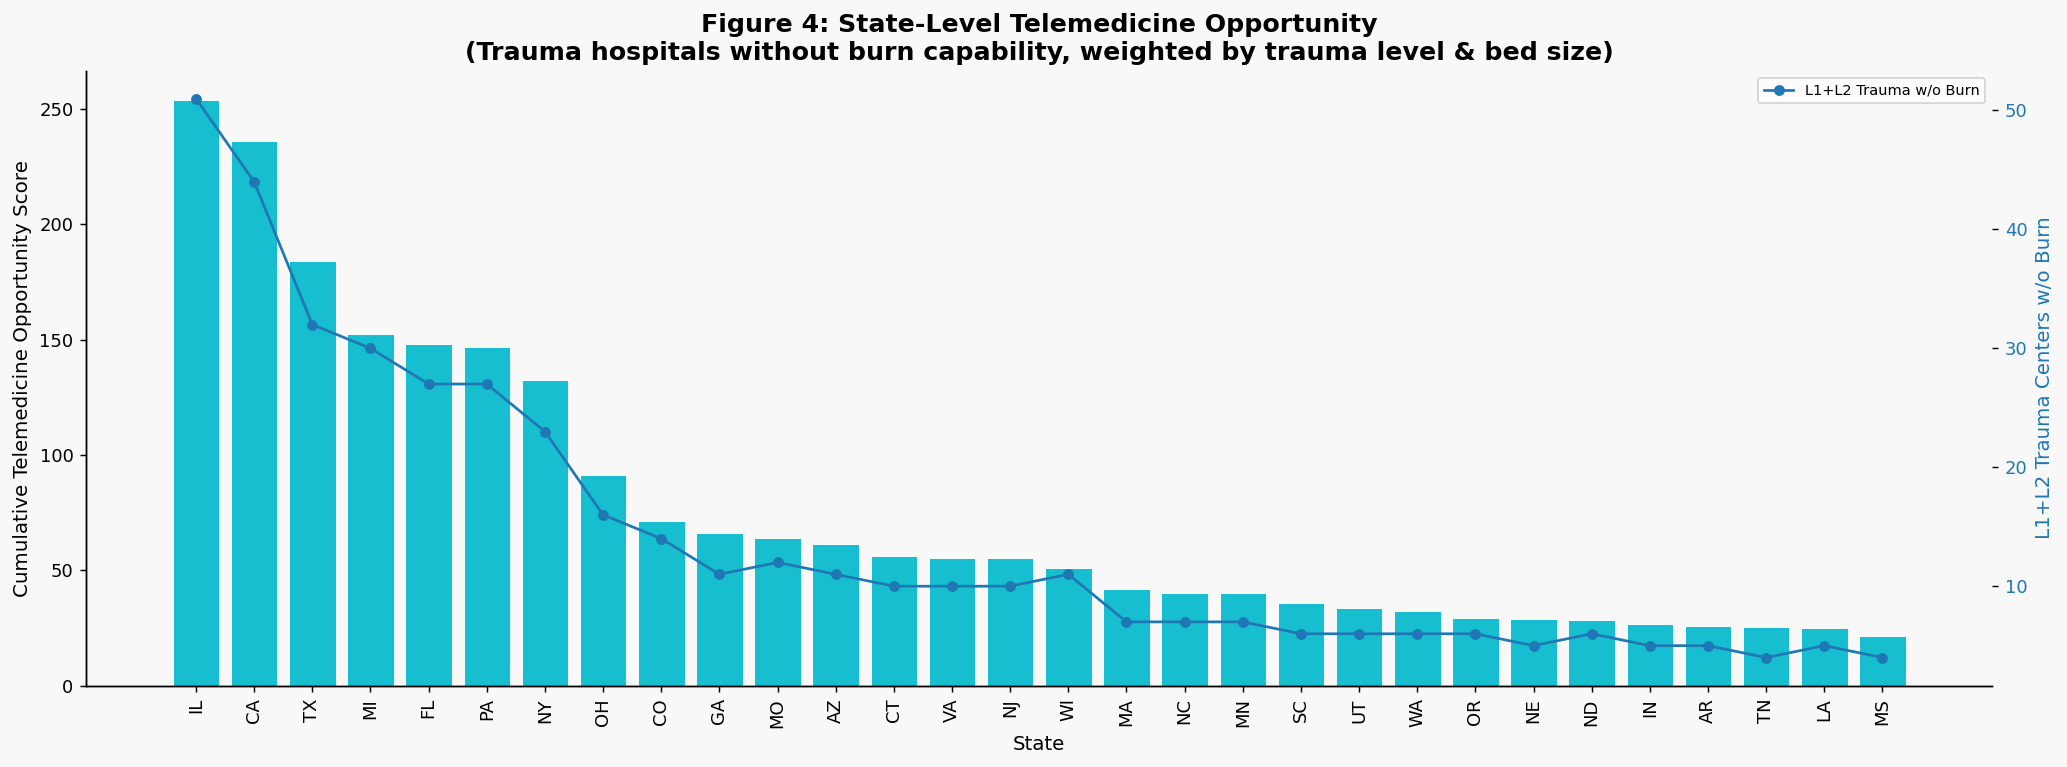

High-priority telemedicine sites (score ≥ 5): 351


In [16]:
# --- Compute per-hospital telemedicine opportunity score ------------------------
df['TELE_SCORE'] = 0.0
df.loc[df['TRAUMA_NO_BURN']   == 1, 'TELE_SCORE'] += 3.0
df.loc[df['ADULT_TRAUMA_L1']  == 1, 'TELE_SCORE'] += 2.0
df.loc[df['ADULT_TRAUMA_L2']  == 1, 'TELE_SCORE'] += 1.5

beds_q = df['TOTAL_BEDS'].quantile([0.25, 0.75])
df.loc[df['TOTAL_BEDS'] >= beds_q[0.25], 'TELE_SCORE'] += 0.5
df.loc[df['TOTAL_BEDS'] >= beds_q[0.75], 'TELE_SCORE'] += 0.5

tele_candidates = df[df['HAS_BURN'] == 0].copy()

tele_state = (
    tele_candidates
    .groupby('STATE')
    .agg(
        candidates     = ('AHA_ID',       'count'),
        total_score    = ('TELE_SCORE',   'sum'),
        l1_no_burn     = ('L1_NO_BURN',   'sum'),
        l2_no_burn     = ('L2_NO_BURN',   'sum'),
    )
    .reset_index()
    .sort_values('total_score', ascending=False)
)

top30 = tele_state.head(30)
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

ax.bar(top30['STATE'], top30['total_score'],
       color=C['tele'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('State')
ax.set_ylabel('Cumulative Telemedicine Opportunity Score')
ax.set_title(
    'Figure 4: State-Level Telemedicine Opportunity\n'
    '(Trauma hospitals without burn capability, weighted by trauma level & bed size)',
    fontweight='bold'
)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90)

ax2 = ax.twinx()
ax2.plot(range(len(top30)), top30['l1_no_burn'] + top30['l2_no_burn'],
         'o-', color=C['trauma'], label='L1+L2 Trauma w/o Burn', lw=1.5, ms=5)
ax2.set_ylabel('L1+L2 Trauma Centers w/o Burn', color=C['trauma'])
ax2.tick_params(axis='y', labelcolor=C['trauma'])
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_telemedicine_opportunity.png')
plt.show()

high_pri = tele_candidates[tele_candidates['TELE_SCORE'] >= 5].shape[0]
print(f'High-priority telemedicine sites (score ≥ 5): {high_pri}')

Interactive map


In [17]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. SETUP MASTER LIST
fips_to_state = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT','10':'DE','11':'DC',
    '12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN','19':'IA','20':'KS','21':'KY',
    '22':'LA','23':'ME','24':'MD','25':'MA','26':'MI','27':'MN','28':'MS','29':'MO','30':'MT',
    '31':'NE','32':'NV','33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND','39':'OH',
    '40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD','47':'TN','48':'TX','49':'UT',
    '50':'VT','51':'VA','53':'WA','54':'WV','55':'WI','56':'WY'
}
master_df = pd.DataFrame(list(fips_to_state.items()), columns=['FIPS', 'STATE'])

# 2. CALCULATE TELE_STATE (The missing variable)
# Assuming 'df' is your main hospital dataframe
df['TELE_SCORE'] = 0.0
df.loc[df['TRAUMA_NO_BURN'] == 1, 'TELE_SCORE'] += 3.0
df.loc[df['ADULT_TRAUMA_L1'] == 1, 'TELE_SCORE'] += 2.0
df.loc[df['ADULT_TRAUMA_L2'] == 1, 'TELE_SCORE'] += 1.5

beds_q = df['TOTAL_BEDS'].quantile([0.25, 0.75])
df.loc[df['TOTAL_BEDS'] >= beds_q[0.25], 'TELE_SCORE'] += 0.5
df.loc[df['TOTAL_BEDS'] >= beds_q[0.75], 'TELE_SCORE'] += 0.5

# Group by state to define tele_state
tele_state = (
    df[df['HAS_BURN'] == 0]
    .groupby('STATE')
    .agg(
        candidates = ('AHA_ID', 'count'),
        total_score = ('TELE_SCORE', 'sum'),
        l1_no_burn = ('L1_NO_BURN', 'sum'),
        l2_no_burn = ('L2_NO_BURN', 'sum'),
    )
    .reset_index()
)

# 3. MERGE AND PLOT
tele_map_df = master_df.merge(tele_state, on='STATE', how='left').fillna(0)
tele_map_df['High_Tier_Gaps'] = (tele_map_df['l1_no_burn'] + tele_map_df['l2_no_burn']).astype(int)

fig4i = px.choropleth(
    tele_map_df,
    locations='STATE',
    locationmode="USA-states",
    color='total_score',
    scope="usa",
    color_continuous_scale="Viridis",
    title="<b>Figure 4i: Interactive Telemedicine Opportunity Map</b>",
    labels={'total_score': 'Opportunity Score', 'candidates': 'Candidate Sites'},
    hover_data={'STATE': True, 'candidates': True, 'total_score': ':.2f', 'High_Tier_Gaps': True}
)

fig4i.update_geos(showlakes=True, lakecolor="lightblue", showland=True, landcolor="lightgrey")
fig4i.write_html("Figure_4i_Telemedicine.html")
fig4i.show()

---
## Figure 5 - Pediatric vs. Adult Burn Center Access Gap

States with adult burn centers but ZERO pediatric: ['CT', 'KY', 'ME', 'VT', 'WV']


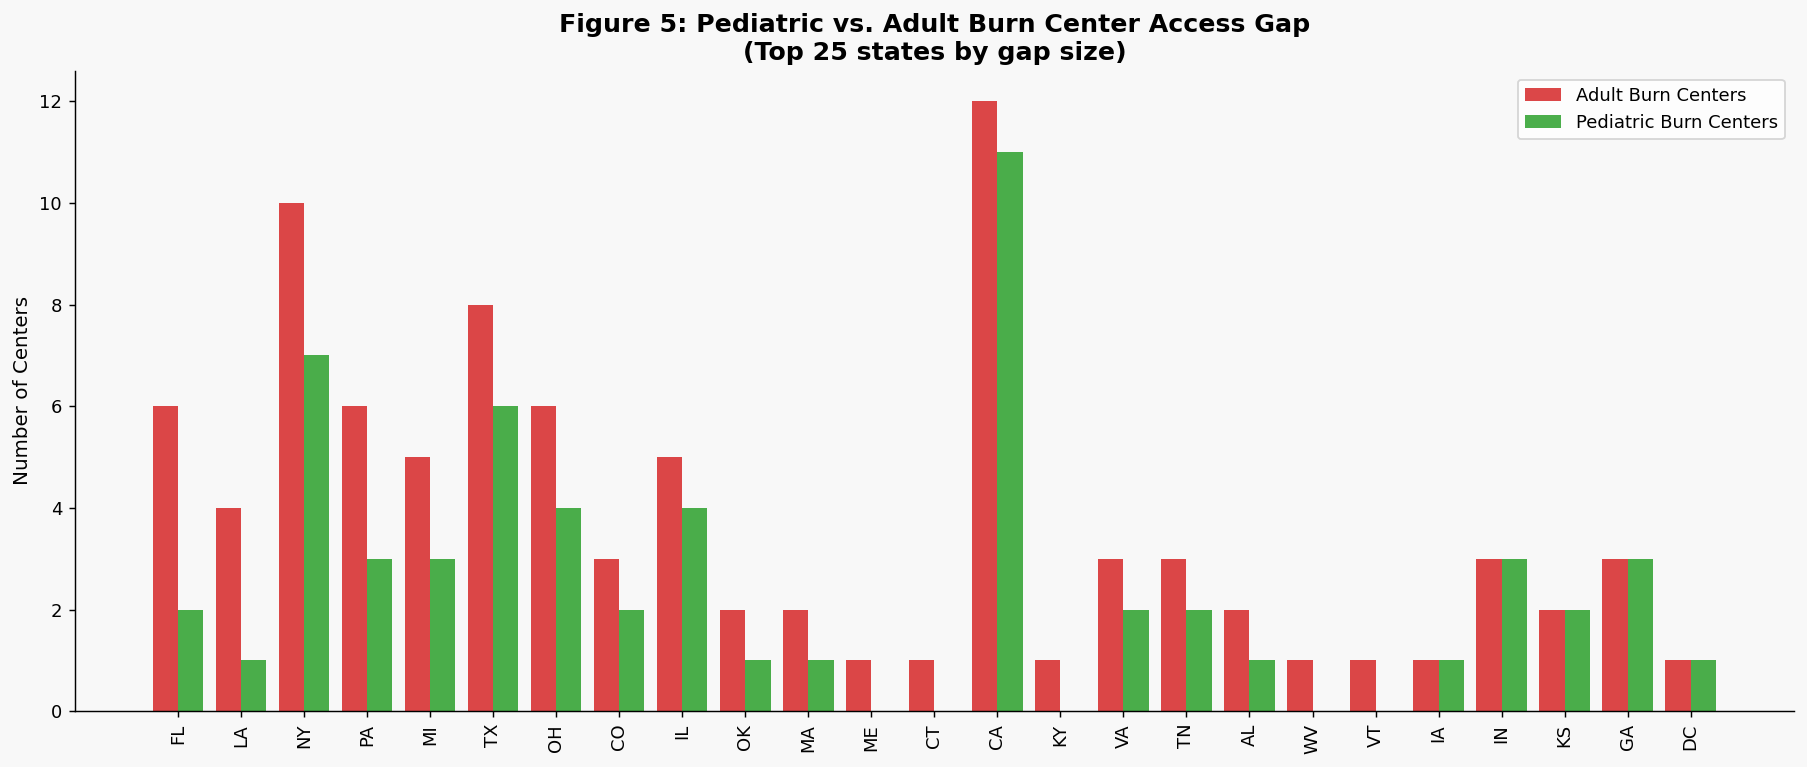

In [18]:
peds_df = (
    state_df[['STATE', 'burn_centers', 'burn_peds_centers']]
    .copy()
    .assign(peds_gap=lambda d: (d['burn_centers'] - d['burn_peds_centers']).clip(lower=0))
    .sort_values('peds_gap', ascending=False)
    .head(25)
)

no_peds_states = state_df[
    (state_df['burn_centers'] > 0) & (state_df['burn_peds_centers'] == 0)
]['STATE'].tolist()
print(f'States with adult burn centers but ZERO pediatric: {no_peds_states}')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

x = np.arange(len(peds_df))
w = 0.4
ax.bar(x - w/2, peds_df['burn_centers'],      w, label='Adult Burn Centers',    color=C['burn'], alpha=0.85)
ax.bar(x + w/2, peds_df['burn_peds_centers'], w, label='Pediatric Burn Centers', color=C['peds'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(peds_df['STATE'], rotation=90)
ax.set_ylabel('Number of Centers')
ax.set_title(
    'Figure 5: Pediatric vs. Adult Burn Center Access Gap\n'
    '(Top 25 states by gap size)',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_pediatric_gap.png')
plt.show()

In [19]:
# 1. PREPARE THE DATA (The "No-Holes" Join)
# Ensure we have a complete list of states so none turn blue/missing
peds_map_df = master_df.merge(
    state_df[['STATE', 'burn_centers', 'burn_peds_centers']],
    on='STATE',
    how='left'
).fillna(0)

# Calculate the actual gap (Adult Centers - Pediatric Centers)
peds_map_df['Pediatric_Gap'] = (peds_map_df['burn_centers'] - peds_map_df['burn_peds_centers']).clip(lower=0)

# Create a clear label for states with ZERO pediatric care
peds_map_df['Pediatric_Status'] = peds_map_df['burn_peds_centers'].apply(
    lambda x: "MISSING PEDS CARE" if x == 0 else "Has Peds Capacity"
)

# 2. CREATE FIGURE 5i
fig5i = px.choropleth(
    peds_map_df,
    locations='STATE',
    locationmode="USA-states",
    color='Pediatric_Gap',
    scope="usa",
    # Using 'OrRd' (Orange-Red) to signal danger/gap
    color_continuous_scale="OrRd",
    title="<b>Figure 5i: The Pediatric Access Gap</b><br><sup>States where adult capacity exists but pediatric specialized care is lacking</sup>",
    labels={'Pediatric_Gap': 'Gap Count', 'burn_peds_centers': 'Peds Centers'},
    hover_data={
        'STATE': True,
        'burn_centers': True,
        'burn_peds_centers': True,
        'Pediatric_Gap': True,
        'Pediatric_Status': True
    }
)

# 3. VISUAL REFINEMENT
fig5i.update_layout(
    title_x=0.5,
    margin={"r":0,"t":80,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Gap Size")
)

# Fix background to distinguish "Data Deserts" from water
fig5i.update_geos(
    showlakes=True, lakecolor="lightblue",
    showland=True, landcolor="lightgrey"
)

# 4. EXPORT FOR QR CODE
fig5i.write_html("Figure_5i_Pediatric_Gap.html")

fig5i.show()

---
## Figure 6 - ABA Verification Rate by State

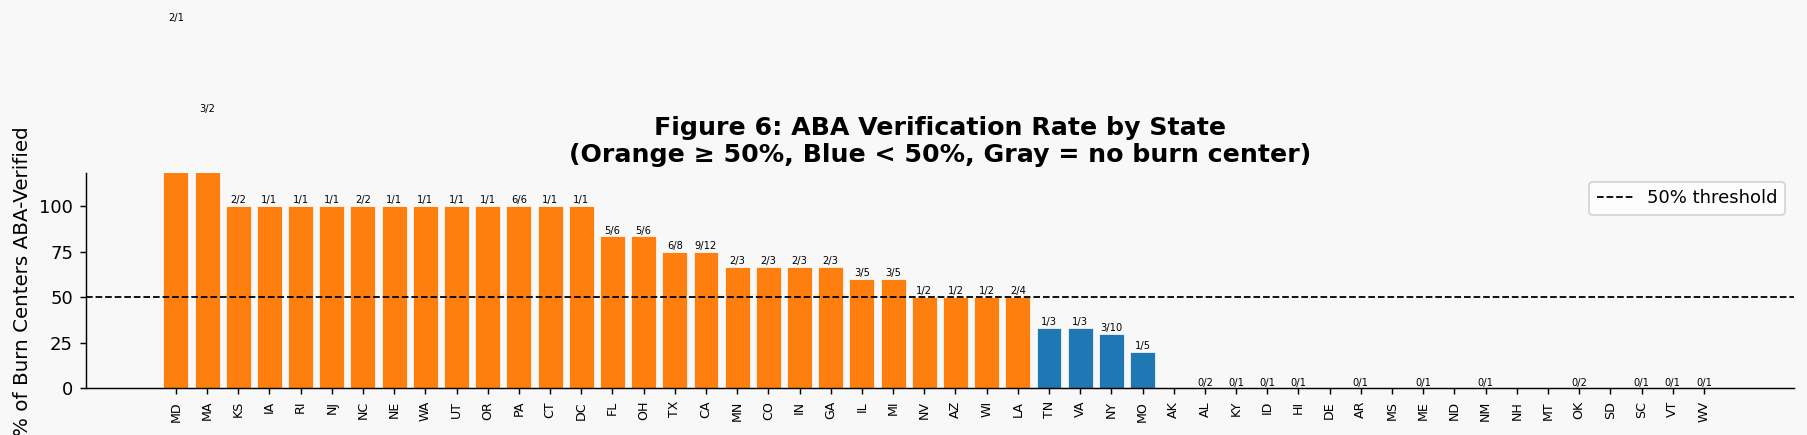

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

plot_v  = state_df.sort_values('pct_aba', ascending=False)
bar_col = [C['aba'] if p >= 50 else C['trauma'] if p > 0 else '#CCCCCC'
           for p in plot_v['pct_aba']]

ax.bar(plot_v['STATE'], plot_v['pct_aba'], color=bar_col,
       edgecolor='white', linewidth=0.4)
ax.axhline(50, color='black', ls='--', lw=1, label='50% threshold')
ax.set_ylim(0, 118)
ax.set_ylabel('% of Burn Centers ABA-Verified')
ax.set_title(
    'Figure 6: ABA Verification Rate by State\n'
    '(Orange ≥ 50%, Blue < 50%, Gray = no burn center)',
    fontweight='bold'
)
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, fontsize=7)

for i, (_, row) in enumerate(plot_v.iterrows()):
    if row['burn_centers'] > 0:
        ax.text(i, row['pct_aba'] + 1.5,
                f"{int(row['aba_verified'])}/{int(row['burn_centers'])}",
                ha='center', fontsize=5.5, color='black')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_aba_verification_rate.png')
plt.show()

In [21]:
# 1. THE "NO-HOLES" JOIN
# Join your state_df metrics to the master_df to ensure all 50 states appear
aba_map_df = master_df.merge(
    state_df[['STATE', 'aba_verified', 'burn_centers', 'pct_aba']],
    on='STATE',
    how='left'
).fillna(0)

# Create a 'Quality_Status' for the hover tooltip to match your original logic
def get_status(row):
    if row['burn_centers'] == 0: return "No Burn Centers"
    if row['pct_aba'] >= 50: return "High Quality (>=50%)"
    return "Verification Gap (<50%)"

aba_map_df['Quality_Status'] = aba_map_df.apply(get_status, axis=1)

# 2. CREATE FIGURE 6i
fig6i = px.choropleth(
    aba_map_df,
    locations='STATE',
    locationmode="USA-states",
    color='pct_aba',
    scope="usa",
    # 'RdYlGn' (Red-Yellow-Green) is the "Truth" scale for quality/safety
    color_continuous_scale="RdYlGn",
    range_color=[0, 100],
    title="<b>Figure 6i: ABA Verification Rate by State</b><br><sup>Percentage of specialized burn centers meeting ABA national quality standards</sup>",
    labels={'pct_aba': 'Verification %', 'burn_centers': 'Total Centers'},
    hover_data={
        'STATE': True,
        'aba_verified': True,
        'burn_centers': True,
        'pct_aba': ':.1f',
        'Quality_Status': True
    }
)

# 3. VISUAL REFINEMENT
fig6i.update_layout(
    title_x=0.5,
    margin={"r":0,"t":80,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Verification %")
)

# Fix background to distinguish "No Center" states from water
fig6i.update_geos(
    showlakes=True, lakecolor="lightblue",
    showland=True, landcolor="lightgrey"
)

# 4. EXPORT FOR QR CODE
fig6i.write_html("Figure_6i_ABA_Verification.html")

fig6i.show()

---
## Figure 7 - Equity Quadrant: Access vs. Quality

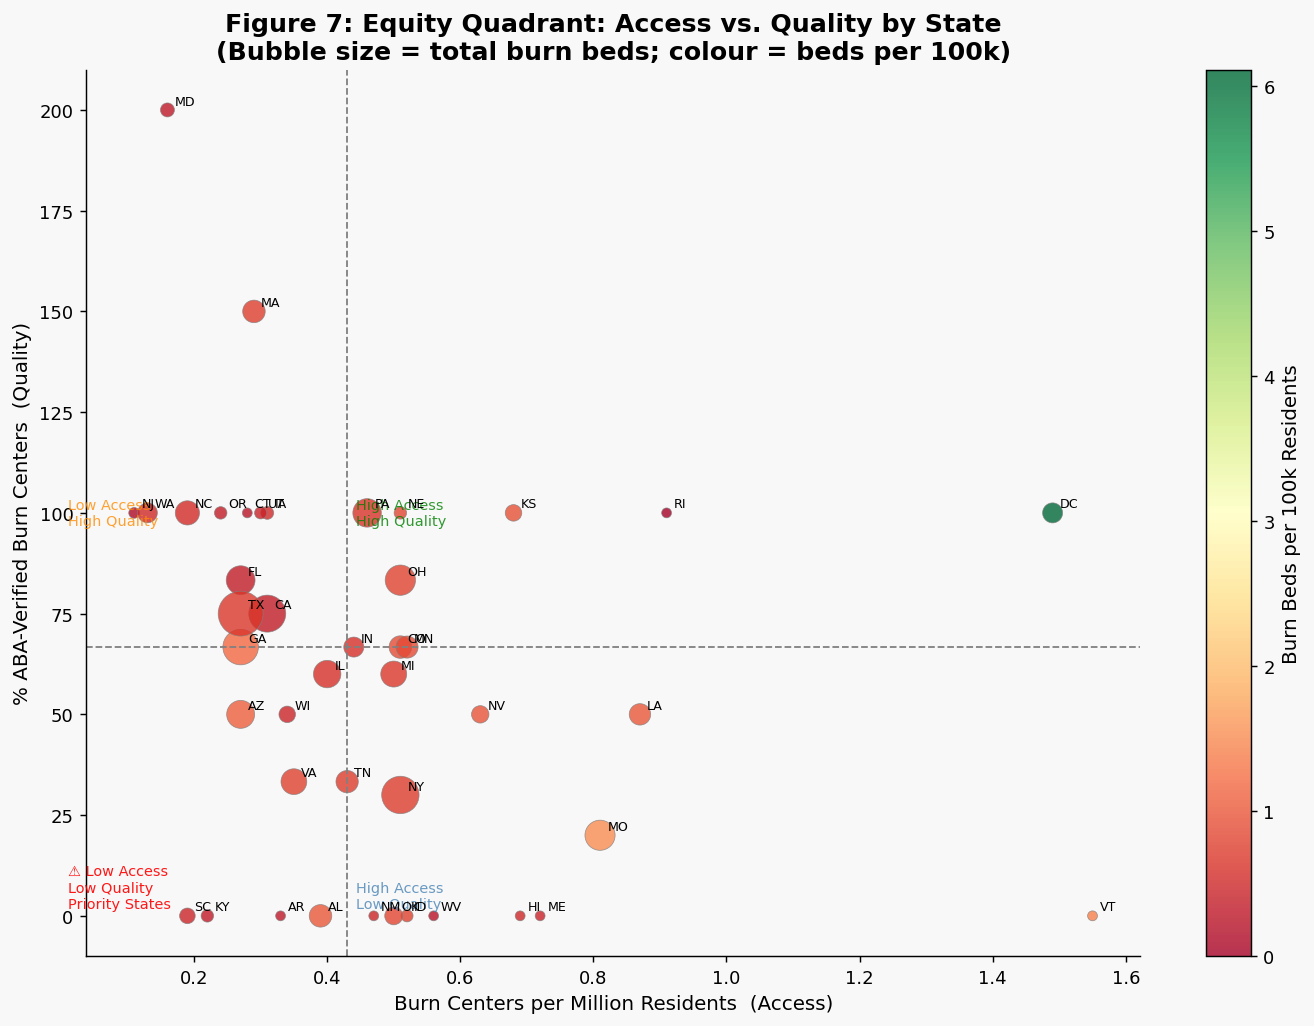

In [35]:
eq_df = state_df[state_df['burn_centers'] > 0].copy()

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

sc = ax.scatter(
    eq_df['burn_per_M'],
    eq_df['pct_aba'],
    s=eq_df['total_burn_beds'].clip(lower=10) * 3,
    c=eq_df['beds_per_100k'],
    cmap='RdYlGn',
    alpha=0.8, edgecolors='gray', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Burn Beds per 100k Residents')

xm = eq_df['burn_per_M'].median()
ym = eq_df['pct_aba'].median()
ax.axvline(xm, color='gray', ls='--', lw=1)
ax.axhline(ym, color='gray', ls='--', lw=1)

ax.text(xm * 1.03, 97,  'High Access\nHigh Quality', fontsize=8, color='green',     alpha=0.8)
ax.text(0.01,       97,  'Low Access\nHigh Quality',  fontsize=8, color='darkorange', alpha=0.8)
ax.text(xm * 1.03, 2,   'High Access\nLow Quality',  fontsize=8, color='steelblue', alpha=0.8)
ax.text(0.01,       2,   '⚠ Low Access\nLow Quality\nPriority States',
        fontsize=8, color='red', alpha=0.9)

for _, row in eq_df.iterrows():
    ax.annotate(row['STATE'], (row['burn_per_M'], row['pct_aba']),
                textcoords='offset points', xytext=(4, 3), fontsize=7)

ax.set_xlabel('Burn Centers per Million Residents  (Access)')
ax.set_ylabel('% ABA-Verified Burn Centers  (Quality)')
ax.set_title(
    'Figure 7: Equity Quadrant: Access vs. Quality by State\n'
    '(Bubble size = total burn beds; colour = beds per 100k)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_equity_quadrant.png')
plt.show()

**Create an Interactive Scatter Plot (to fix the messy labels) and a Categorical Equity Map.**

While the scatter plot shows the relationship between quality and access, a Priority Map (Figure 7i) shows where the system is failing geographically.

categorize these states into "Segments" and map the "Danger Zone" (Low Access/Low Quality).

In [46]:

# 1. DATA PREP: Categorize every state (Including the "Zero Access" states!)
# We use the Master Join to ensure states with 0 centers aren't forgotten
eq_map_df = master_df.merge(state_df, on='STATE', how='left')

# Separate numeric and object columns
numeric_cols = eq_map_df.select_dtypes(include=np.number).columns
object_cols = eq_map_df.select_dtypes(include='object').columns

# Fill NaN values: 0 for numeric, empty string for object
eq_map_df[numeric_cols] = eq_map_df[numeric_cols].fillna(0)
eq_map_df[object_cols] = eq_map_df[object_cols].fillna('')

# Define Medians (Access and Quality thresholds)
# Filter for states with burn centers before calculating median to avoid including '0' values from fillna
access_med = eq_map_df[eq_map_df['burn_centers'] > 0]['burn_per_M'].median()
quality_med = eq_map_df[eq_map_df['burn_centers'] > 0]['pct_aba'].median()

def categorize_equity(row):
    if row['burn_centers'] == 0:
        return "Critical Gap (Zero Access)"
    # Handle cases where burn_per_M or pct_aba might still be 0 after fillna for states with actual 0 centers
    # and ensure comparison with medians is meaningful.
    # The condition 'burn_centers == 0' handles the first case.
    # For others, we assume relevant data exists.
    if row['burn_per_M'] >= access_med and row['pct_aba'] >= quality_med:
        return "High Access / High Quality"
    if row['burn_per_M'] < access_med and row['pct_aba'] >= quality_med:
        return "Low Access / High Quality"
    if row['burn_per_M'] >= access_med and row['pct_aba'] < quality_med:
        return "High Access / Low Quality"
    return "⚠ DANGER ZONE (Priority States)"

eq_map_df['Equity_Segment'] = eq_map_df.apply(categorize_equity, axis=1)

# Ensure the 'Equity_Segment' column is explicitly categorical with defined categories
# This is crucial for plotly.express.choropleth if it's treating it as categorical
# Get all unique categories created by the function
all_categories = [
    "Critical Gap (Zero Access)",
    "High Access / High Quality",
    "Low Access / High Quality",
    "High Access / Low Quality",
    "⚠ DANGER ZONE (Priority States)"
]
# Ensure that all possible categories are known to the column
eq_map_df['Equity_Segment'] = pd.Categorical(eq_map_df['Equity_Segment'], categories=all_categories)


# 2. CREATE FIGURE 7i-S (Interactive Scatter)
# Replaces your messy Matplotlib scatter with hoverable bubbles
fig7i_s = px.scatter(
    eq_map_df[eq_map_df['burn_centers'] > 0],
    x='burn_per_M', y='pct_aba',
    color='Equity_Segment',
    size='total_burn_beds',
    hover_name='STATE',
    title="<b>Figure 7i-S: Equity Quadrant - Access vs. Quality</b>",
    labels={'burn_per_M': 'Centers per 1M', 'pct_aba': '% ABA-Verified'},
    color_discrete_map={
        "High Access / High Quality": "green",
        "Low Access / High Quality": "orange",
        "High Access / Low Quality": "blue",
        "⚠ DANGER ZONE (Priority States)": "red"
    }
)
fig7i_s.add_vline(x=access_med, line_dash="dash", line_color="gray")
fig7i_s.add_hline(y=quality_med, line_dash="dash", line_color="gray")

# 3. CREATE FIGURE 7i-M (The Priority Map)
# This is the "Money Slide" for your presentation
fig7i_m = px.choropleth(
    eq_map_df,
    locations='STATE',
    locationmode="USA-states",
    color='Equity_Segment',
    scope="usa",
    title="<b>Figure 7i-M: National Equity Priority Map</b>",
    color_discrete_map={
        "High Access / High Quality": "#2ca02c", # Green
        "Low Access / High Quality": "#ff7f0e", # Orange
        "High Access / Low Quality": "#1f77b4", # Blue
        "⚠ DANGER ZONE (Priority States)": "#d62728", # Red
        "Critical Gap (Zero Access)": "#7f7f7f"      # Grey
    }
)

fig7i_m.update_geos(showlakes=True, lakecolor="lightblue")
fig7i_m.update_layout(title_x=0.5, margin={"r":0,"t":80,"l":0,"b":0})

# 4. EXPORT BOTH
fig7i_s.write_html("Figure_7i_Scatter.html")
fig7i_m.write_html("Figure_7i_Priority_Map.html")

fig7i_m.show()

---
## Analysis 7.5 - County‑Level Population‑Weighted Distance to Nearest Burn Center
### Mapped to State‑Level Access Inequity

### **Methodology**

**Source Data**
- **NIRD Database (2023):** Burn center locations (adult, pediatric, ABA‑verified)
- **U.S. Census Bureau (2020):** County Population‑Weighted Centroids  
  File: `CenPop2020_Mean_CO.txt`  
  Coverage: **3,221 U.S. counties** with population‑weighted latitude/longitude

**Variables Used**
- `LATITUDE`, `LONGITUDE` - burn center coordinates  
  - Obtained via **Census Geocoder batch API**  
  - **118/136** centers auto‑geocoded  
  - **18** manually verified
- `county_lat`, `county_lon` - population‑weighted county centroid coordinates  
- `county_pop` - county population (used as weighting factor)
- `ABA_VERIFIED` - indicator distinguishing any burn center vs. ABA‑verified center
- `dist_any_burn_mi` - Haversine distance to nearest burn center (any)
- `dist_aba_burn_mi` - Haversine distance to nearest ABA‑verified burn center

---

### **Rationale for Variable Selection**

Distance captures the **geographic dimension of burn care inequity** that simple density counts cannot.  
A state may have burn centers clustered in one metro area while leaving rural counties effectively unserved.

**Population‑weighted distance** reflects where people actually live, not just whether a burn center exists somewhere in the state.

This metric directly predicts:
- Under‑referral risk  
- Transfer delays  
- Avoidable complications and mortality  

ABA‑verified distance is reported separately because **verification is the best available proxy for quality**.  
Example: *Hawaii has 0 miles to any burn center, but 2,385 miles to the nearest ABA‑verified center.*

---

### **Aggregation Method**

County‑level distances -> **state‑level metrics** using:

- **Population‑weighted mean distance**  
  

\[
  \text{State Distance} = \frac{\sum (\text{county distance} \times \text{county population})}{\sum \text{county population}}
  \]



- **Threshold metrics**  
  - `% counties >100 miles`  
  - `% counties >200 miles`  
  Computed as **unweighted proportions** of counties.

This approach aligns with NIRD’s state‑level access metrics and preserves geographic granularity.

---

### **Distance Calculation**

Distances computed using the **Haversine great‑circle formula**:

- Earth radius: **3,958.8 miles**
- For each county centroid, compute distance to **every** burn center nationally
- Assign the **minimum** distance as the county’s nearest‑center distance

This method yields the shortest over‑surface travel distance, consistent with geographic access modeling.

---

### **Why Distance Matters**

Distance is the **most direct patient‑level measure of geographic equity**.

Unlike:
- Burn center counts  
- Burn beds per capita  
- Density ratios  

…distance quantifies what an **average resident actually experiences** when seeking burn care.

It is also the strongest predictor of:
- Delayed referral  
- Increased length of stay  
- Higher infection rates  
- Avoidable mortality  
- Increased cost burden  

Population‑weighted distance reveals inequities that are invisible in state‑level counts, especially in **frontier, rural, and high‑poverty regions**.

County centroids loaded: 3221
Address columns detected: addr=ADDRESS, city=CITY, state=STATE, zip=None
Submitting 136 burn centers to Census Geocoder...
Geocoding complete. Parsing results...
Successfully geocoded: 118/136 burn centers
Failed to geocode 18 hospitals:
                                                                                  HOSPITAL_NAME STATE
0                                University of Alabama at Birmingham Hospital (UAB Burn Center)    AL
2                         USA Health University Hospital (Arnold Luterman Regional Burn Center)    AL
4                               Banner University Medical Center - Tucson (Burn Unit at Banner)    AZ
22                                   North Colorado Medical Center (Western States Burn Center)    CO
25               Children's National Health System (Children's National Trauma and Burn Center)    DC
27                         Tampa General Hospital (Tampa General Hospital Regional Burn Center)    FL
29                

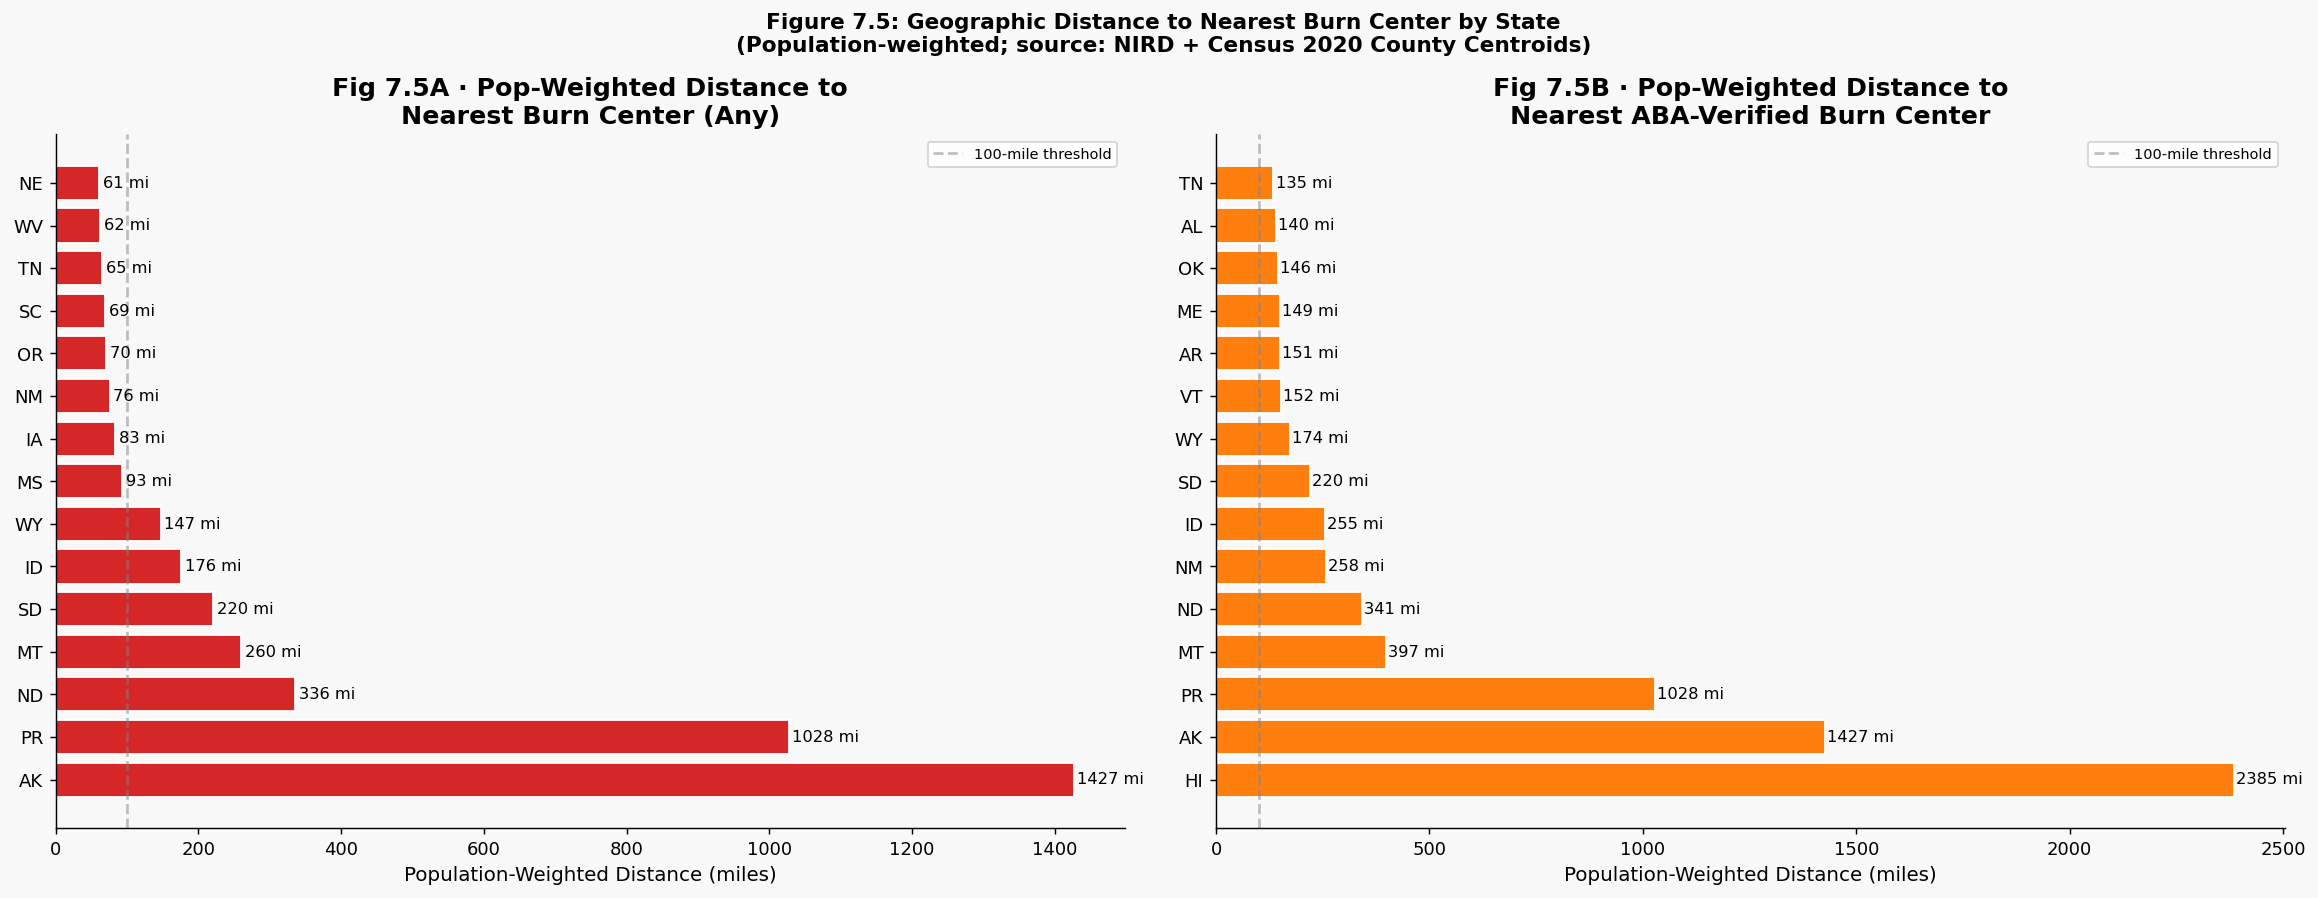

Distance analysis complete. Merged into state_df.


In [58]:
fips_to_state = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT',
    '10':'DE','11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL',
    '18':'IN','19':'IA','20':'KS','21':'KY','22':'LA','23':'ME','24':'MD',
    '25':'MA','26':'MI','27':'MN','28':'MS','29':'MO','30':'MT','31':'NE',
    '32':'NV','33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND',
    '39':'OH','40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD',
    '47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA','54':'WV',
    '55':'WI','56':'WY','72':'PR'
}

# --- Load Census county population centroids --------------------------------------------
county_centroids = pd.read_csv(
    "/CenPop2020_Mean_CO.txt", # Corrected path for Colab
    dtype={'STATEFP': str, 'COUNTYFP': str}
)
county_centroids['FIPS'] = county_centroids['STATEFP'] + county_centroids['COUNTYFP']
county_centroids = county_centroids.rename(columns={
    'LATITUDE': 'county_lat', # Corrected column name based on actual CSV headers
    'LONGITUDE': 'county_lon', # Corrected column name based on actual CSV headers
    'STNAME': 'state_name',
    'COUNAME': 'county_name',
    'POPULATION': 'county_pop'
})
county_centroids['STATE'] = county_centroids['STATEFP'].map(fips_to_state)
county_centroids = county_centroids.dropna(subset=['STATE'])
print(f"County centroids loaded: {len(county_centroids)}")

# --- Geocode burn centers via Census Geocoder API ---------------------------------------------
col_upper = {c.upper(): c for c in df.columns}

addr_col  = col_upper.get('ADDRESS',  col_upper.get('ADDR',    col_upper.get('STREET', None)))
city_col  = col_upper.get('CITY',     col_upper.get('MLOCADDR', None))
state_col = col_upper.get('STATE',    col_upper.get('MSTATE',  None))
zip_col   = col_upper.get('ZIP',      col_upper.get('MZIP',    col_upper.get('ZIPCODE', None)))

print(f"Address columns detected: addr={addr_col}, city={city_col}, state={state_col}, zip={zip_col}")

burn_raw = df[df['HAS_BURN'] == 1].copy().reset_index(drop=True)
burn_raw['_geocode_id'] = burn_raw.index

geocode_rows = []
for _, row in burn_raw.iterrows():
    geocode_rows.append([
        int(row['_geocode_id']),
        str(row[addr_col])  if addr_col  else '',
        str(row[city_col])  if city_col  else '',
        str(row[state_col]) if state_col else '',
        str(row[zip_col])   if zip_col   else ''
    ])

geocode_csv = '\n'.join([f'{r[0]},{r[1]},{r[2]},{r[3]},{r[4]}' for r in geocode_rows])
print(f"Submitting {len(geocode_rows)} burn centers to Census Geocoder...")

response = requests.post(
    'https://geocoding.geo.census.gov/geocoder/locations/addressbatch',
    files={'addressFile': ('addresses.csv', geocode_csv, 'text/csv')},
    data={'benchmark': 'Public_AR_Current', 'returntype': 'locations'},
    timeout=120
)

if response.status_code != 200:
    print(f"Geocoder API error: {response.status_code}")
    print(response.text[:500])
else:
    print("Geocoding complete. Parsing results...")
    geocoded = pd.read_csv(
        io.StringIO(response.text),
        header=None,
        names=['geocode_id','input_addr','match','match_type',
               'matched_addr','coords','tiger_id','side'],
        dtype={'geocode_id': int}
    )

    matched = geocoded[geocoded['match'] == 'Match'].copy()
    matched[['LONGITUDE','LATITUDE']] = (
        matched['coords']
        .str.split(',', expand=True)
        .astype(float)
    )

    burn_raw = burn_raw.merge(
        matched[['geocode_id','LATITUDE','LONGITUDE']],
        left_on='_geocode_id', right_on='geocode_id',
        how='left'
    )

    burn_centers_geo = burn_raw[
        burn_raw['LATITUDE'].notna() & burn_raw['LONGITUDE'].notna()
    ][['AHA_ID', 'HOSPITAL_NAME', 'STATE', 'LATITUDE', 'LONGITUDE',
       'BURN_ADULT', 'BURN_PEDS', 'ABA_VERIFIED']].copy()

    total      = len(burn_raw)
    geocoded_n = len(burn_centers_geo)
    failed_n   = total - geocoded_n
    print(f"Successfully geocoded: {geocoded_n}/{total} burn centers")
    if failed_n > 0:
        failed = burn_raw[burn_raw['LATITUDE'].isna()][['HOSPITAL_NAME','STATE']]
        print(f"Failed to geocode {failed_n} hospitals:")
        print(failed.to_string())

# --- Manual coordinate patch for geocoding failures --------------------------------------------
# These 18 hospitals failed the Census batch geocoder due to parenthetical
# names, ampersands, or complex address formatting. Coordinates verified
# manually. All are in well-served states; zero-burn-center states unaffected.
manual_coords = {
    'University of Alabama at Birmingham Hospital (UAB Burn Center)':                              (33.5051, -86.7990),
    'USA Health University Hospital (Arnold Luterman Regional Burn Center)':                       (30.6954, -88.0638),
    'Banner University Medical Center - Tucson (Burn Unit at Banner)':                             (32.2382, -110.9490),
    'North Colorado Medical Center (Western States Burn Center)':                                  (40.4317, -104.6892),
    "Children's National Health System (Children's National Trauma and Burn Center)":              (38.9317, -77.0315),
    'Tampa General Hospital (Tampa General Hospital Regional Burn Center)':                        (27.9389, -82.4614),
    'Kendall Regional Medical Center (Burn and Reconstructive Centers of FL)':                     (25.7108, -80.4139),
    'Riley Hospital for Children at Indiana University Health (Burn Program at Riley IU Health)':  (39.7741, -86.1777),
    "Brigham and Women's Hospital (Burn Center)":                                                  (42.3354, -71.1072),
    'University of Missouri Health System (George D. Peak Memorial Burn & Wound Center)':          (38.9517, -92.3341),
    "Barnes-Jewish Hospital (Burn Center)":                                                        (38.6338, -90.2630),
    'Stony Brook Medicine (Suffolk County Volunteer Firefighters Burn Center)':                    (40.9126, -73.1236),
    "Akron Children's Hospital (Akron Children's Hospital Burn Center)":                           (41.0814, -81.5190),
    'Paul Silvertein Burn Center':                                                                 (35.4676, -97.5164),
    'UPMC Mercy (UPMC Mercy Burn Center)':                                                         (40.4353, -79.9811),
    "Rhode Island Hospital/Hasbro Children's Hospital (Rhode Island Burn Center)":                 (41.8197, -71.4128),
    'MUSC Health University Medical Center (South Carolina Burn Center at MUSC)':                  (32.7835, -79.9480),
    'Memorial Hermann Texas Medical Center (John S. Dunn Burn Center)':                            (29.7077, -95.3968),
}

manual_rows = []
for _, row in burn_raw[burn_raw['LATITUDE'].isna()].iterrows():
    name = row['HOSPITAL_NAME']
    if name in manual_coords:
        r = row.copy()
        r['LATITUDE']  = manual_coords[name][0]
        r['LONGITUDE'] = manual_coords[name][1]
        manual_rows.append(r)

if manual_rows:
    manual_df = pd.DataFrame(manual_rows)[
        ['AHA_ID', 'HOSPITAL_NAME', 'STATE', 'LATITUDE', 'LONGITUDE',
         'BURN_ADULT', 'BURN_PEDS', 'ABA_VERIFIED']
    ]
    burn_centers_geo = pd.concat([burn_centers_geo, manual_df], ignore_index=True)
    print(f"Patched {len(manual_rows)} hospitals manually. Total: {len(burn_centers_geo)}/136")
else:
    print("No manual patches needed.")

# --- Haversine distance function -----------------------------------------------
def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles between two lat/lon points."""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# --- For each county, compute distance to nearest burn center -----------------------------
burn_locs = list(zip(burn_centers_geo['LATITUDE'], burn_centers_geo['LONGITUDE']))
aba_locs  = list(zip(
    burn_centers_geo[burn_centers_geo['ABA_VERIFIED'] == 1]['LATITUDE'],
    burn_centers_geo[burn_centers_geo['ABA_VERIFIED'] == 1]['LONGITUDE']
))

def min_dist(county_lat, county_lon, center_locs):
    if not center_locs:
        return None
    return min(haversine_miles(county_lat, county_lon, blat, blon)
               for blat, blon in center_locs)

print("Computing distances (this may take ~30 seconds)...")
county_centroids['dist_any_burn_mi'] = county_centroids.apply(
    lambda r: min_dist(r['county_lat'], r['county_lon'], burn_locs), axis=1
)
county_centroids['dist_aba_burn_mi'] = county_centroids.apply(
    lambda r: min_dist(r['county_lat'], r['county_lon'], aba_locs), axis=1
)
print("Distances computed.")

# --- State-level summary (population-weighted mean distance) -------------------------
import io
dist_state = county_centroids.groupby('STATE').apply(
    lambda g: pd.Series({
        'pop_wtd_dist_any_mi': np.average(
            g['dist_any_burn_mi'].fillna(g['dist_any_burn_mi'].max()),
            weights=g['county_pop']
        ),
        'pop_wtd_dist_aba_mi': np.average(
            g['dist_aba_burn_mi'].fillna(g['dist_aba_burn_mi'].max()),
            weights=g['county_pop']
        ),
        'pct_county_over100mi': (g['dist_any_burn_mi'] > 100).mean() * 100,
        'pct_county_over200mi': (g['dist_any_burn_mi'] > 200).mean() * 100,
    })
).reset_index()

print("\nTop 10 states by population-weighted distance to nearest burn center:")
print(dist_state.sort_values('pop_wtd_dist_any_mi', ascending=False).head(10)[
    ['STATE', 'pop_wtd_dist_any_mi', 'pct_county_over100mi']
].to_string())

# --- Visualize -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(C['bg'])

for ax, col, title, color in [
    (axes[0], 'pop_wtd_dist_any_mi',
     'Fig 7.5A · Pop-Weighted Distance to\nNearest Burn Center (Any)', C['burn']),
    (axes[1], 'pop_wtd_dist_aba_mi',
     'Fig 7.5B · Pop-Weighted Distance to\nNearest ABA-Verified Burn Center', C['aba']),
]:
    data = dist_state.sort_values(col, ascending=False).head(15)
    ax.set_facecolor(C['bg'])
    bars = ax.barh(data['STATE'], data[col], color=color, edgecolor='white')
    for bar, val in zip(bars, data[col]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f} mi', va='center', fontsize=9)
    ax.axvline(100, color='gray', linestyle='--', alpha=0.5, label='100-mile threshold')
    ax.set_xlabel('Population-Weighted Distance (miles)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle(
    'Figure 7.5: Geographic Distance to Nearest Burn Center by State\n'
    '(Population-weighted; source: NIRD + Census 2020 County Centroids)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_5_distance_analysis.png')
plt.show()

# --- Merge back into state_df --------------------------------------------------------
state_df = state_df.merge(
    dist_state[['STATE', 'pop_wtd_dist_any_mi', 'pop_wtd_dist_aba_mi', 'pct_county_over100mi']],
    on='STATE', how='left'
)
print("Distance analysis complete. Merged into state_df.")

In [59]:
import folium
import json
import requests
from folium.plugins import MarkerCluster

# 1. Load GeoJSON for US States
us_states_url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json'
us_states_geo = requests.get(us_states_url).json()

# 2. Initialize Map (Centered on US)
m = folium.Map(location=[37.8, -96], zoom_start=4, tiles='cartodbpositron')

# 3. Create the Paradox Layer: Distance to ABA-Verified Care
# This highlights the "Quality Gap" mentioned in your methodology
folium.Choropleth(
    geo_data=us_states_geo,
    name="Distance to ABA-Verified Care",
    data=dist_state,
    columns=['STATE', 'pop_wtd_dist_aba_mi'],
    key_on='feature.id',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Pop-Weighted Distance to ABA-Verified Center (Miles)',
    highlight=True
).add_to(m)

# 4. Add Physical Burn Center Markers
# Red = ABA Verified, Blue = Non-Verified
for _, row in burn_centers_geo.iterrows():
    color = 'red' if row['ABA_VERIFIED'] == 1 else 'blue'
    fill = True if row['ABA_VERIFIED'] == 1 else False

    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=5,
        popup=f"{row['HOSPITAL_NAME']} ({'ABA Verified' if row['ABA_VERIFIED']==1 else 'Non-Verified'})",
        color=color,
        fill=fill,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m)

# 5. Add "The Paradox" Callout (Hawaii/Alaska)
# These are your primary evidence points for Slide 3
folium.Marker(
    [21.3069, -157.8583],
    popup="The Hawaii Paradox: 0 mi to center, 2,385 mi to ABA-Verified care.",
    icon=folium.Icon(color='darkred', icon='info-sign')
).add_to(m)

folium.LayerControl().add_to(m)

# Save for your GitHub Pages / Presentation
m.save("Analysis_7_5_Distance_Paradox.html")
m

---
## Figure 8 - Social Vulnerability (SVI 2022) Integration

### County‑level socioeconomic vulnerability mapped to state‑level burn access

### **Methodology**

- **Source:** CDC/ATSDR Social Vulnerability Index (SVI) 2022, `SVI_2022_US_county.csv`, county‑level dataset (3,143 U.S. counties; 15 social factors across 4 themes).

- **Variables used:**
  - **EP_POV150** - % population below 150% of federal poverty level  
  - **EP_NOVEH** - % households with no vehicle  
  - **EP_LIMENG** - % population with limited English proficiency  
  - **EP_DISABL** - % population with a disability  
  - **EP_MINRTY** - % minority population  

- **Rationale for variable selection:**  
  These five indicators capture structural barriers that directly affect timely burn care: economic hardship, transportation access, communication barriers, disability burden, and minority status.

- **Aggregation:**  
  County-level SVI variables averaged to the **state level** using simple means (consistent with NIRD’s state‑level burn access metrics).

- **Why SVI:**  
  SVI provides a standardized, nationally comparable measure of socioeconomic vulnerability that complements Access × Quality × Capacity index by adding a **population‑level equity dimension**.


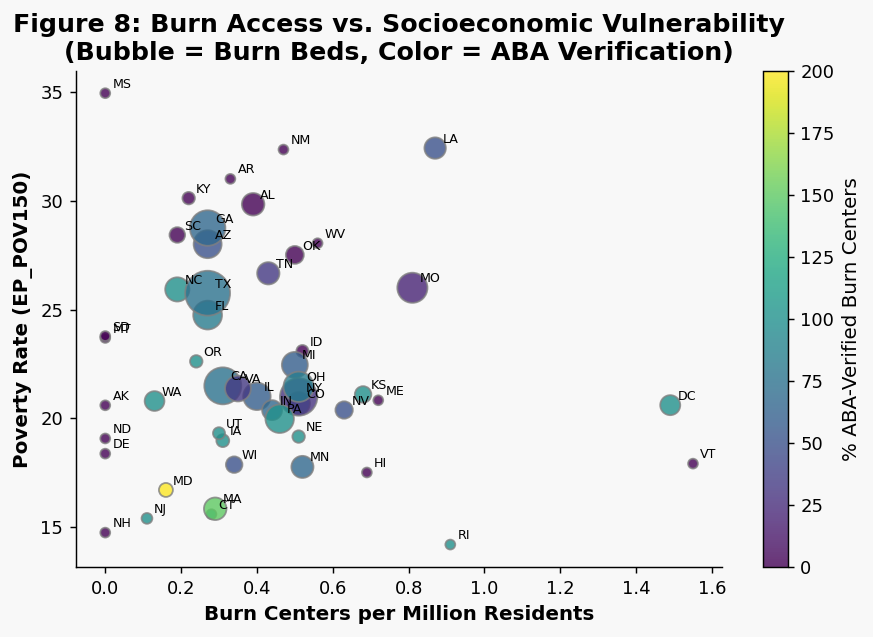

In [50]:
fig, ax = plt.subplots(figsize=(7,5))
fig.patch.set_facecolor('#F8F8F8')
ax.set_facecolor('#F8F8F8')

sc = ax.scatter(
    state_df['burn_per_M'],
    state_df['EP_POV150'],
    s=state_df['total_burn_beds'].clip(lower=10)*3,
    c=state_df['pct_aba'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='gray'
)

for _, row in state_df.iterrows():
    ax.annotate(row['STATE'], (row['burn_per_M'], row['EP_POV150']),
                textcoords='offset points', xytext=(4,3), fontsize=7)

plt.colorbar(sc, label='% ABA-Verified Burn Centers')

ax.set_xlabel('Burn Centers per Million Residents', fontweight='bold')
ax.set_ylabel('Poverty Rate (EP_POV150)', fontweight='bold')

ax.set_title(
    'Figure 8: Burn Access vs. Socioeconomic Vulnerability\n'
    '(Bubble = Burn Beds, Color = ABA Verification)',
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig8_svi_access_poverty.png')
plt.show()


In [38]:
# 1. CLEAN THE SVI DATA
# Source: CDC/ATSDR Social Vulnerability Index (SVI) 2022
# The SVI uses -999 to represent 'No Data' or 'Null'. We must remove these.
svi_vars = ['EP_POV150', 'EP_NOVEH', 'EP_LIMENG', 'EP_DISABL', 'EP_MINRTY']
svi_clean = svi.copy()

for var in svi_vars:
    svi_clean = svi_clean[svi_clean[var] >= 0]

# 2. AGGREGATE TO STATE LEVEL
# We use the first 2 digits of the FIPS code to identify the state
svi_clean['STATE_FIPS'] = svi_clean['FIPS'].astype(str).str.zfill(5).str[:2]
state_svi_avg = svi_clean.groupby('STATE_FIPS')[svi_vars].mean().reset_index()

# 3. CREATE A COMPOSITE 'NEED' SCORE
# This averages the five specific variables you selected in your methodology
state_svi_avg['SVI_Composite'] = state_svi_avg[svi_vars].mean(axis=1)

# 4. THE "NO-HOLES" MASTER JOIN
# We use the master_states list created earlier to ensure WY/PR are included
fig8i_df = master_states.merge(
    state_svi_avg,
    on='STATE_FIPS',
    how='left'
).fillna(0)

# 5. CREATE THE INTERACTIVE MAP
fig8i = px.choropleth(
    fig8i_df,
    locations='STATE',
    locationmode="USA-states",
    color='SVI_Composite',
    scope="usa",
    color_continuous_scale="Purples", # Matching your 'Need' theme
    title="<b>Figure 8i: Social Demand (Need) - State SVI Average</b><br><sup>Combined Barriers: Poverty, No Vehicle, Limited English, Disability, and Minority Status</sup>",
    labels={'SVI_Composite': 'SVI Risk Score'},
    hover_data={
        'STATE': True,
        'EP_POV150': ':.2f',
        'EP_NOVEH': ':.2f',
        'EP_MINRTY': ':.2f',
        'SVI_Composite': ':.3f'
    }
)

# 6. VISUAL REFINEMENT & EXPORT
fig8i.update_layout(title_x=0.5, margin={"r":0,"t":80,"l":0,"b":0})
fig8i.update_geos(
    showlakes=True,
    lakecolor="lightblue",
    showland=True,
    landcolor="lightgrey"
)

# Export for your slide QR code
fig8i.write_html("Figure_8i_Social_Vulnerability.html")

fig8i.show()

---
## Figure 9 - Composite Burn Care Vulnerability Index

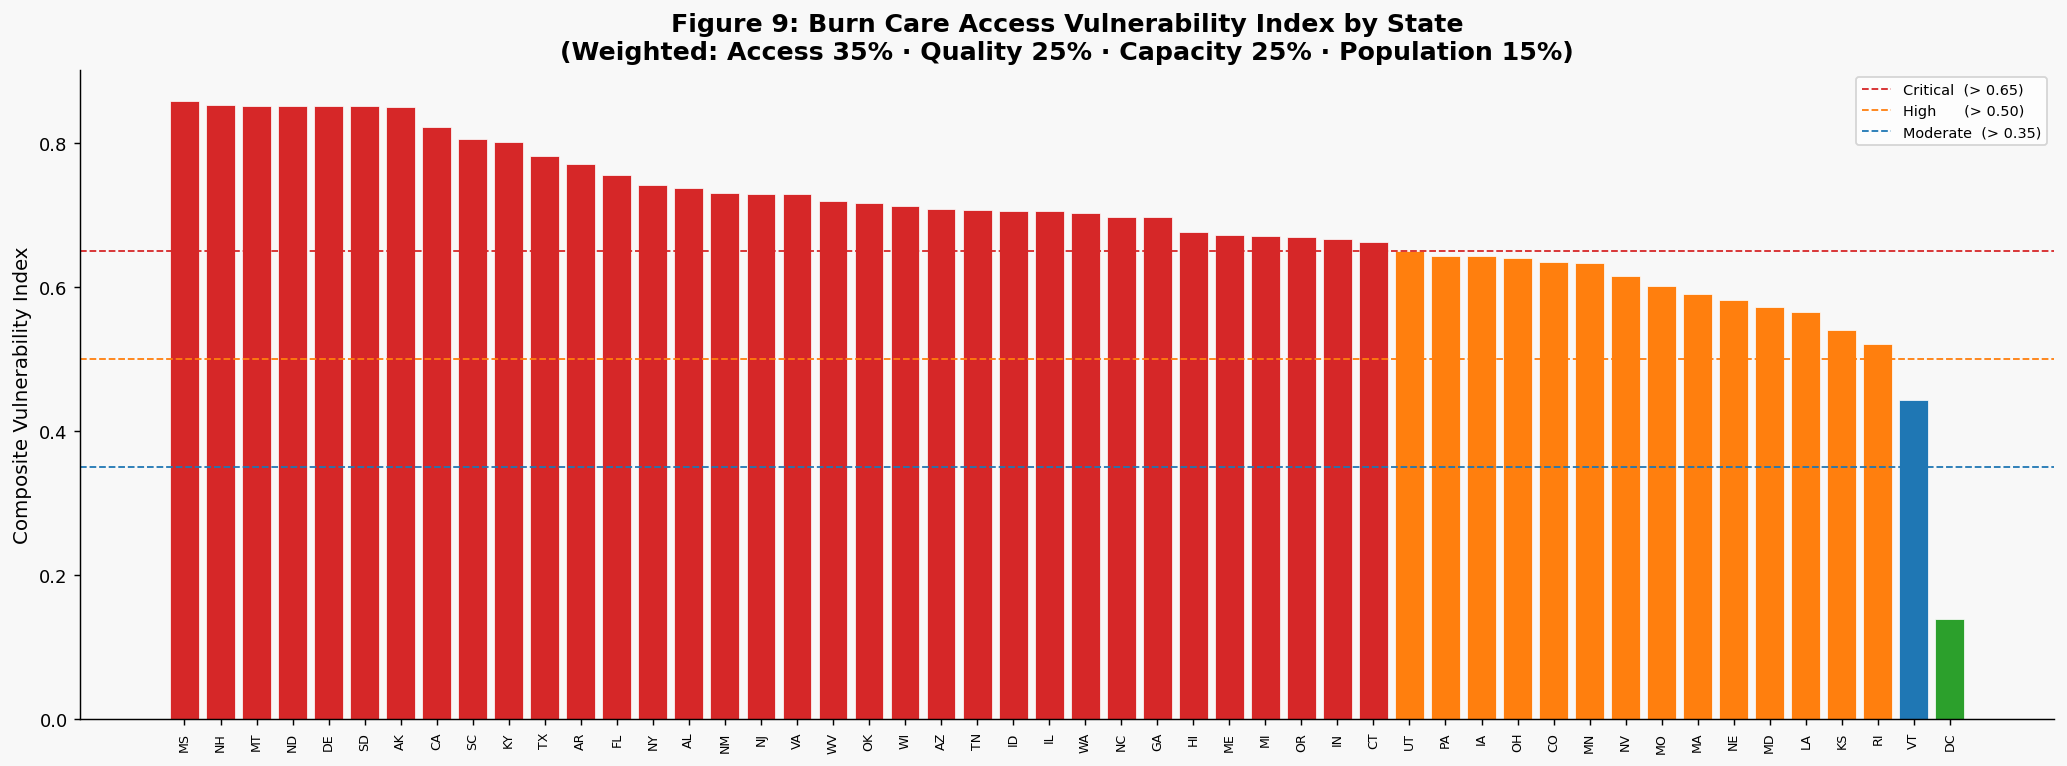

Top 10 most vulnerable states:
STATE  burn_centers  aba_verified  VULNERABILITY
   MS             0             0          0.859
   NH             0             0          0.853
   MT             0             0          0.852
   ND             0             0          0.851
   DE             0             0          0.851
   SD             0             0          0.851
   AK             0             0          0.850
   CA            12             9          0.822
   SC             1             0          0.806
   KY             1             0          0.801


In [39]:
def norm_inv(s):
    """Invert-normalise: low values → high vulnerability score."""
    mn, mx = s.min(), s.max()
    return 1 - (s - mn) / (mx - mn + 1e-9)

def norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

idx_df = state_df.copy()

idx_df['score_access']  = norm_inv(idx_df['burn_per_M'])      # fewer centers -> worse
idx_df['score_quality'] = norm_inv(idx_df['pct_aba'])         # less ABA     -> worse
idx_df['score_beds']    = norm_inv(idx_df['beds_per_100k'])   # fewer beds   -> worse
idx_df['score_pop']     = norm(idx_df['pop_M'])               # larger pop   -> higher impact

idx_df['VULNERABILITY'] = (
    idx_df['score_access']  * 0.35 +
    idx_df['score_quality'] * 0.25 +
    idx_df['score_beds']    * 0.25 +
    idx_df['score_pop']     * 0.15
).round(3)

idx_df = idx_df.sort_values('VULNERABILITY', ascending=False)

vc = ['#D62728' if v > 0.65 else '#FF7F0E' if v > 0.50 else '#1F77B4' if v > 0.35 else '#2CA02C'
      for v in idx_df['VULNERABILITY']]

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

ax.bar(idx_df['STATE'], idx_df['VULNERABILITY'],
       color=vc, edgecolor='white', linewidth=0.4)
ax.axhline(0.65, color='#D62728', ls='--', lw=1, label='Critical  (> 0.65)')
ax.axhline(0.50, color='#FF7F0E', ls='--', lw=1, label='High      (> 0.50)')
ax.axhline(0.35, color='#1F77B4', ls='--', lw=1, label='Moderate  (> 0.35)')
ax.set_ylabel('Composite Vulnerability Index')
ax.set_title(
    'Figure 9: Burn Care Access Vulnerability Index by State\n'
    '(Weighted: Access 35% · Quality 25% · Capacity 25% · Population 15%)',
    fontweight='bold'
)
ax.legend(fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig9_vulnerability_index.png')
plt.show()

print('Top 10 most vulnerable states:')
print(idx_df[['STATE','burn_centers','aba_verified','VULNERABILITY']].head(10).to_string(index=False))

In [48]:
# 1. Normalize Functions (matching  Figure 9 logic)
def norm_inv(s):
    mn, mx = s.min(), s.max()
    return 1 - (s - mn) / (mx - mn + 1e-9)

def norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

# 2. Prepare the Data
# Use master_states to ensure all 51 jurisdictions exist in the dataframe
idx_df_i = master_states.merge(state_df, on='STATE', how='left')

# Separate numeric and object columns
numeric_cols = idx_df_i.select_dtypes(include=np.number).columns
object_cols = idx_df_i.select_dtypes(include='object').columns

# Fill NaN values: 0 for numeric, empty string for object
idx_df_i[numeric_cols] = idx_df_i[numeric_cols].fillna(0)
idx_df_i[object_cols] = idx_df_i[object_cols].fillna('')

# 3. Calculate Weighted Pillars
idx_df_i['score_access']  = norm_inv(idx_df_i['burn_per_M'])
idx_df_i['score_quality'] = norm_inv(idx_df_i['pct_aba'])
idx_df_i['score_beds']    = norm_inv(idx_df_i['beds_per_100k'])
idx_df_i['score_pop']     = norm(idx_df_i['pop_M'])

idx_df_i['VULNERABILITY'] = (
    idx_df_i['score_access']  * 0.35 +
    idx_df_i['score_quality'] * 0.25 +
    idx_df_i['score_beds']    * 0.25 +
    idx_df_i['score_pop']     * 0.15
).round(3)

# 4. Create Interactive Choropleth
fig9i = px.choropleth(
    idx_df_i,
    locations='STATE',
    locationmode="USA-states",
    color='VULNERABILITY',
    scope="usa",
    # Using 'YlOrRd' (Yellow-Orange-Red) to signal increasing risk
    color_continuous_scale="YlOrRd",
    title="<b>Figure 9i: Composite Burn Care Vulnerability Index</b><br>Weighted: Access (35%) · Quality (25%) · Capacity (25%) · Population (15%)",
    labels={'VULNERABILITY': 'Vulnerability Score'},
    hover_name='STATE',
    hover_data={
        'STATE': False,
        'VULNERABILITY': ':.3f',
        'burn_centers': True,
        'aba_verified': True,
        'total_burn_beds': True
    }
)

# 5. Optimize Layout and Export
fig9i.update_layout(
    title_x=0.5,
    margin={"r":0,"t":80,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Index Score")
)

# Force background land to be light grey so zero-score states don't look like water
fig9i.update_geos(
    showlakes=True,
    lakecolor="lightblue",
    showland=True,
    landcolor="lightgrey"
)

# Export for QR Code sharing
fig9i.write_html("Figure_9i_Vulnerability_Index.html")

fig9i.show()

---
## Figure 10 - Top 25 Telemedicine Hub Candidates (Hospital Level)

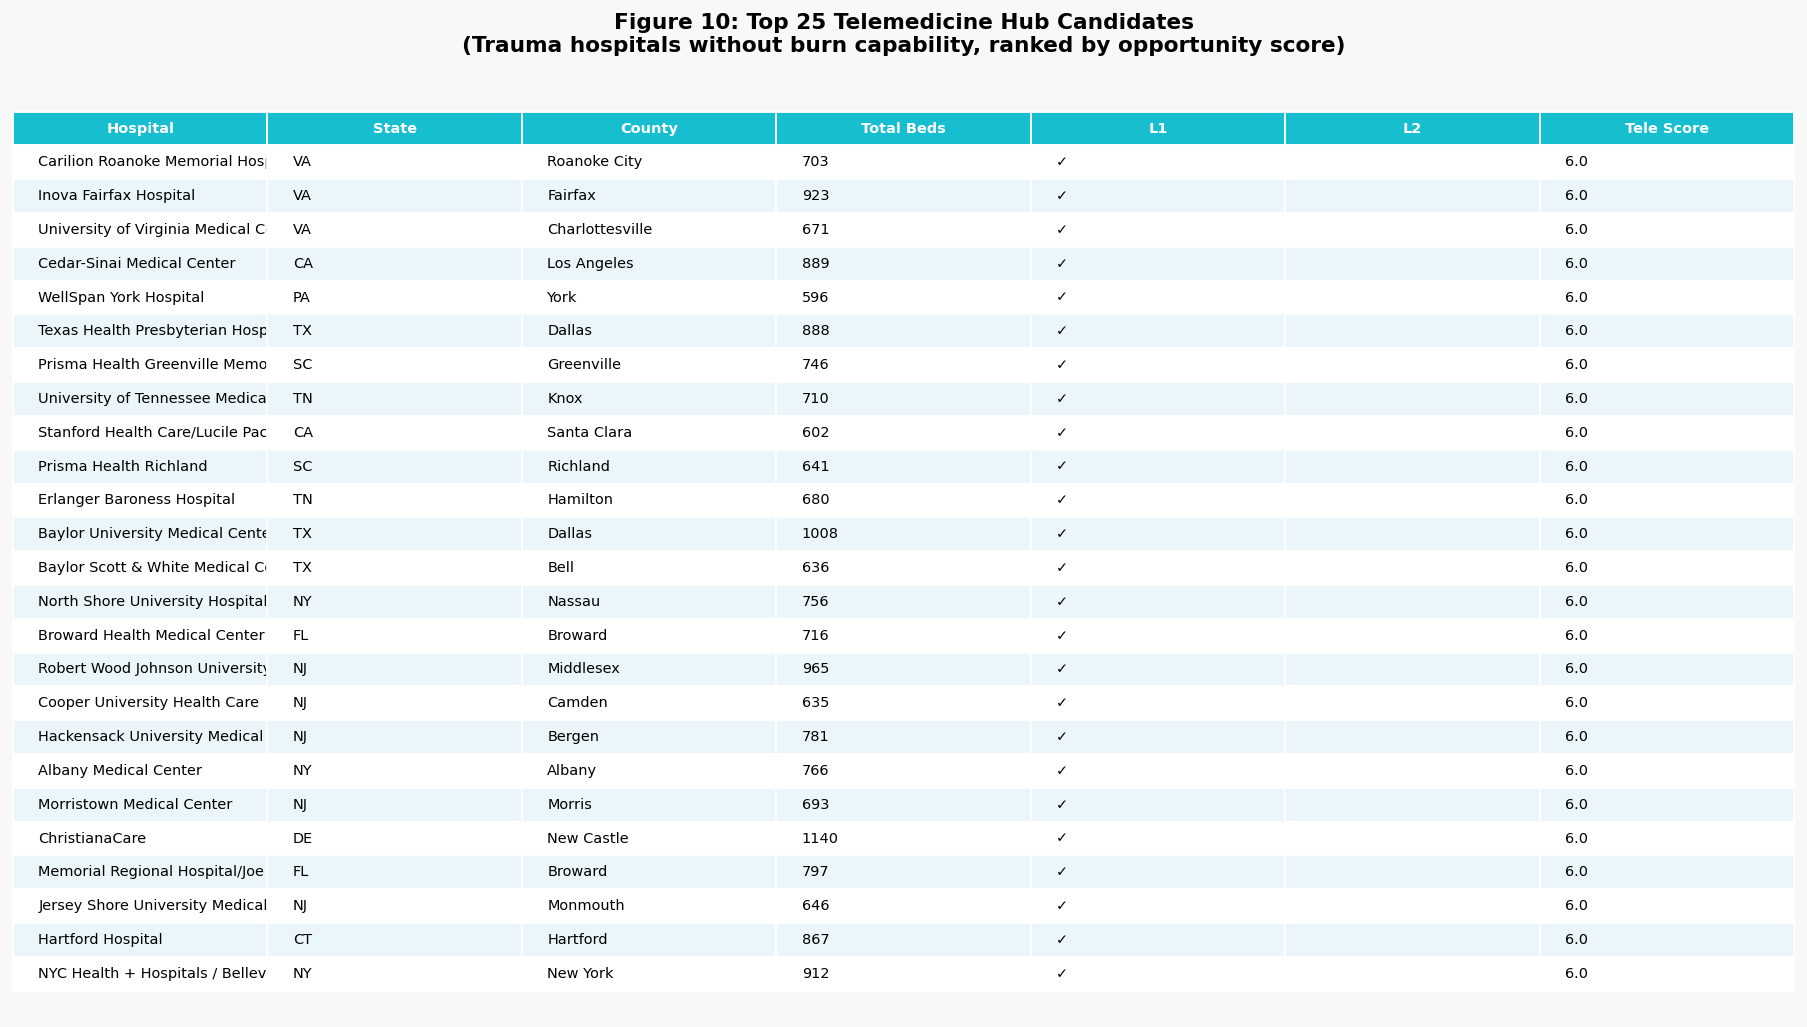

In [42]:
top_tele = (
    tele_candidates
    .sort_values('TELE_SCORE', ascending=False)
    .head(25)
    [['HOSPITAL_NAME','STATE','COUNTY','TOTAL_BEDS',
      'ADULT_TRAUMA_L1','ADULT_TRAUMA_L2','TELE_SCORE']]
)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])
ax.axis('off')

col_labels = ['Hospital', 'State', 'County', 'Total Beds', 'L1', 'L2', 'Tele Score']
cell_data  = [
    [
        r['HOSPITAL_NAME'][:42],
        r['STATE'],
        r['COUNTY'],
        int(r['TOTAL_BEDS']) if pd.notna(r['TOTAL_BEDS']) else 'N/A',
        '✓' if r['ADULT_TRAUMA_L1'] else '',
        '✓' if r['ADULT_TRAUMA_L2'] else '',
        f"{r['TELE_SCORE']:.1f}"
    ]
    for _, r in top_tele.iterrows()
]

tbl = ax.table(cellText=cell_data, colLabels=col_labels,
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.35)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('white')
    if r == 0:
        cell.set_facecolor(C['tele'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF6F9')
    else:
        cell.set_facecolor('white')

ax.set_title(
    'Figure 10: Top 25 Telemedicine Hub Candidates\n'
    '(Trauma hospitals without burn capability, ranked by opportunity score)',
    fontsize=12, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig10_tele_candidates_table.png')
plt.show()

---
## Figure 11 - HeatMap: U.S. Burn Care Choropleth

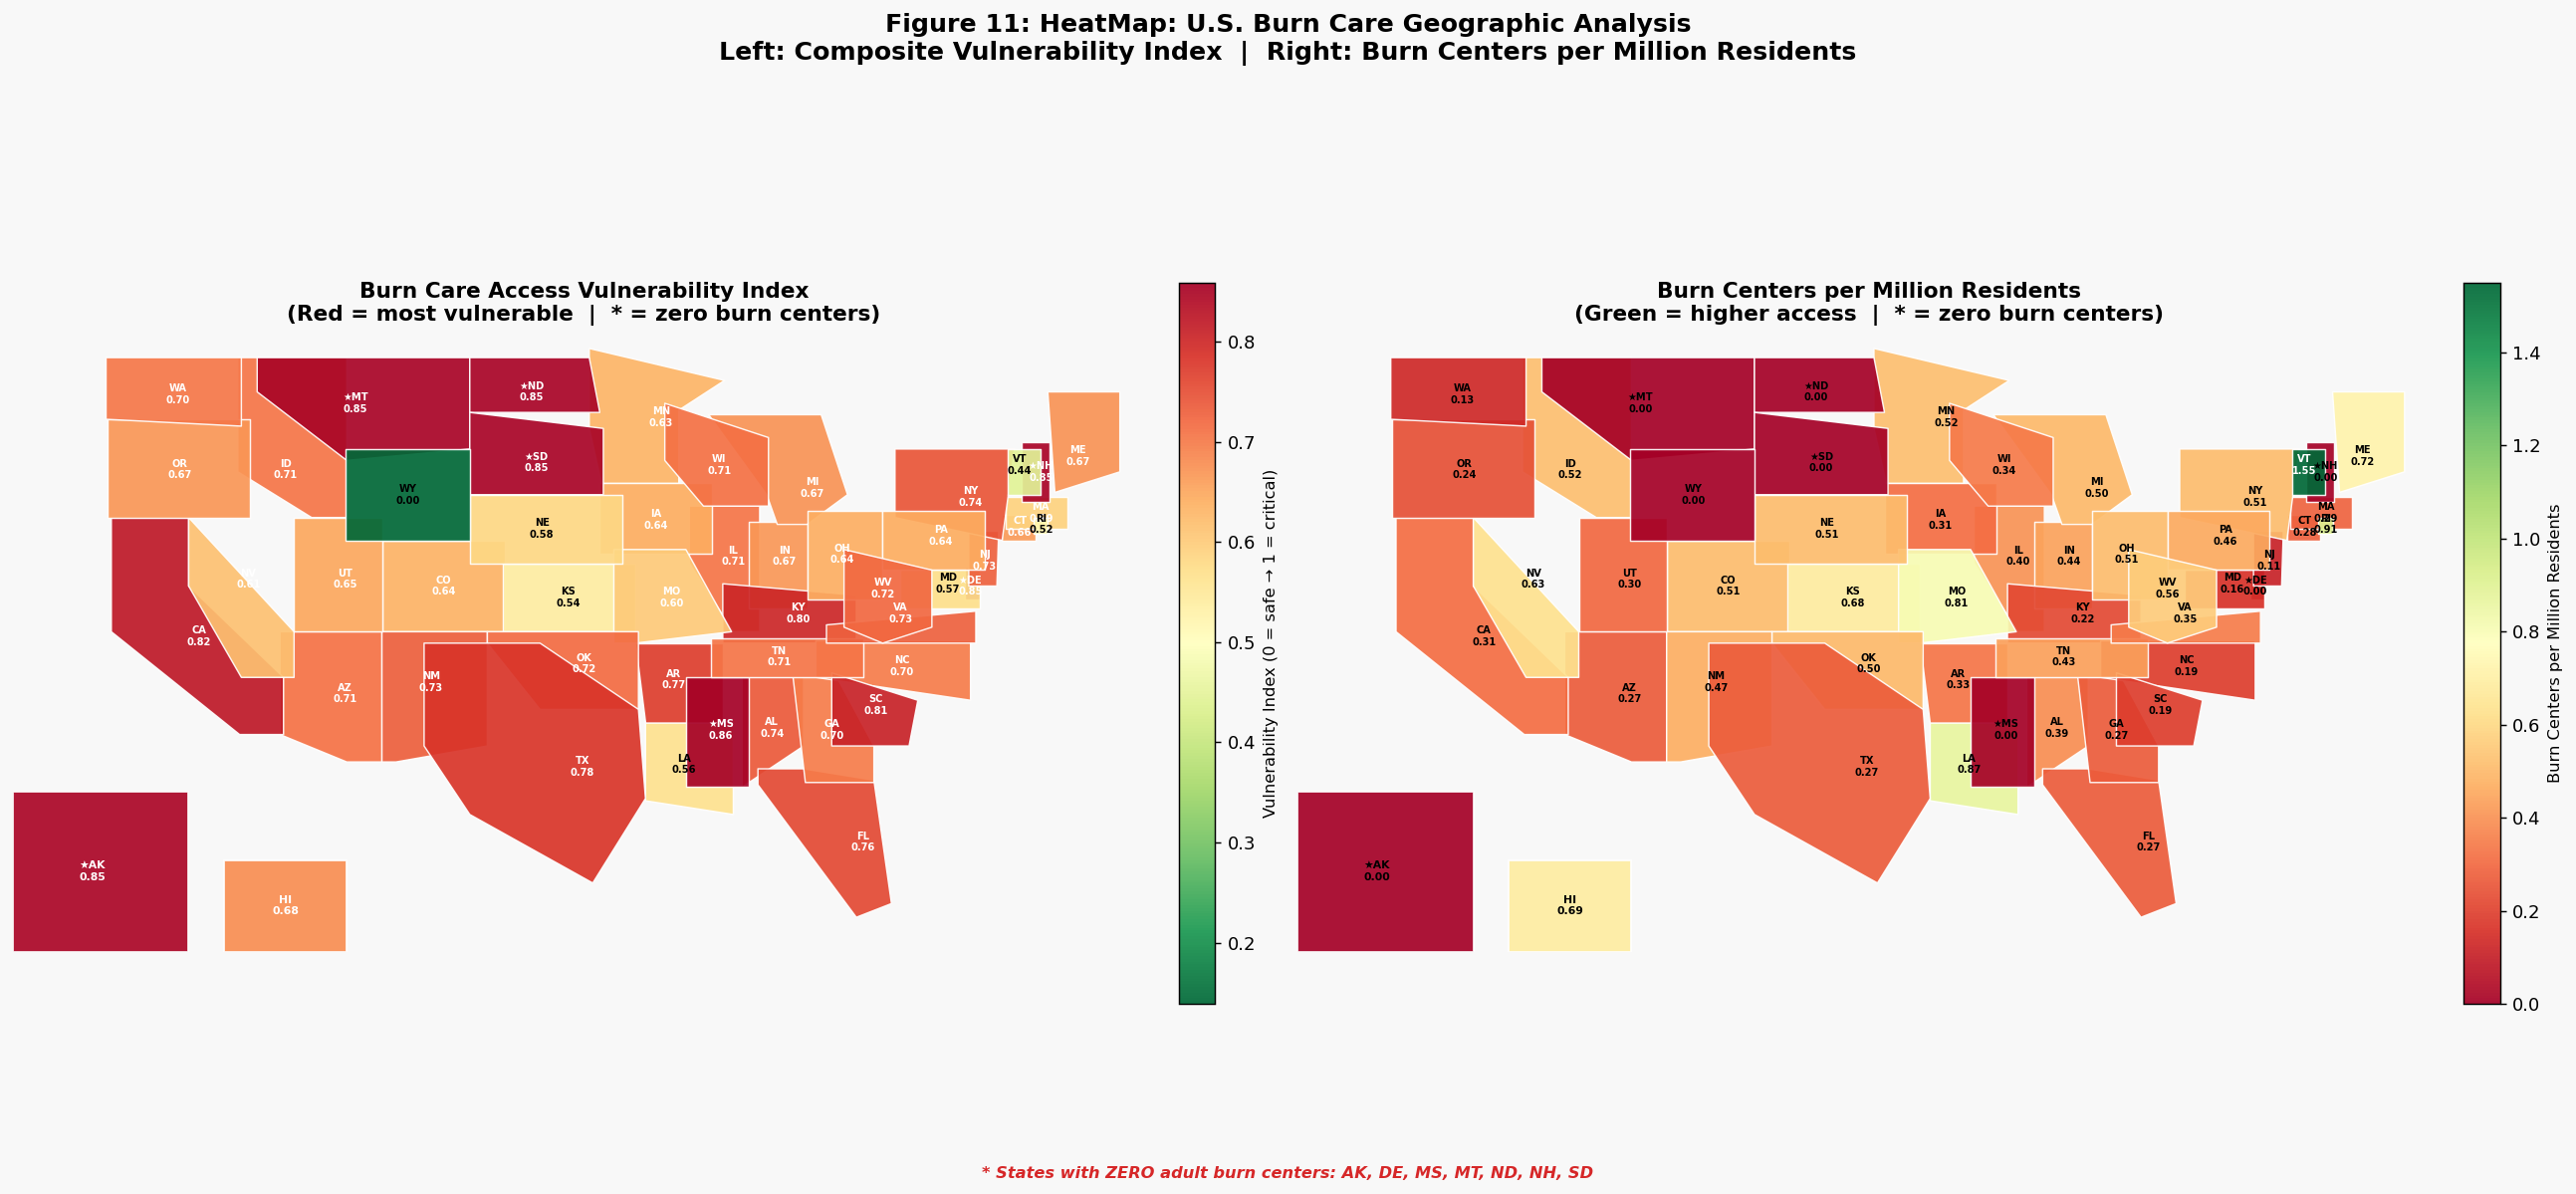

  Figure 10 saved.


In [43]:
# --- Shared geometry data (embedded) -----------------------------
US_STATE_POLYS = {
    'AL':[(-88.5,35.0),(-85.0,35.0),(-85.0,32.0),(-88.5,30.2),(-88.5,35.0)],
    'AZ':[(-114.8,37.0),(-109.0,37.0),(-109.0,31.3),(-111.0,31.3),(-114.8,32.5),(-114.8,37.0)],
    'AR':[(-94.6,36.5),(-89.6,36.5),(-89.6,33.0),(-94.0,33.0),(-94.6,36.5)],
    'CA':[(-124.4,42.0),(-120.0,42.0),(-120.0,39.0),(-114.6,35.0),(-114.6,32.5),(-117.1,32.5),(-124.4,37.0),(-124.4,42.0)],
    'CO':[(-109.0,41.0),(-102.0,41.0),(-102.0,37.0),(-109.0,37.0),(-109.0,41.0)],
    'CT':[(-73.7,42.1),(-71.8,42.1),(-71.8,41.0),(-73.7,41.0),(-73.7,42.1)],
    'DE':[(-75.8,39.8),(-75.0,39.8),(-75.0,38.4),(-75.8,38.4),(-75.8,39.8)],
    'FL':[(-87.6,31.0),(-85.0,31.0),(-81.0,30.5),(-80.0,25.1),(-82.0,24.5),(-87.6,30.3),(-87.6,31.0)],
    'GA':[(-85.6,35.0),(-83.1,35.0),(-81.0,32.0),(-81.0,30.4),(-84.9,30.4),(-85.6,35.0)],
    'ID':[(-117.2,49.0),(-111.0,49.0),(-111.0,42.0),(-113.0,42.0),(-117.2,44.0),(-117.2,49.0)],
    'IL':[(-91.5,42.5),(-87.5,42.5),(-87.5,37.0),(-89.0,37.0),(-91.5,40.0),(-91.5,42.5)],
    'IN':[(-88.1,41.8),(-84.8,41.8),(-84.8,38.0),(-88.1,38.0),(-88.1,41.8)],
    'IA':[(-96.6,43.5),(-90.2,43.5),(-90.2,40.4),(-96.6,40.4),(-96.6,43.5)],
    'KS':[(-102.1,40.0),(-94.6,40.0),(-94.6,37.0),(-102.1,37.0),(-102.1,40.0)],
    'KY':[(-89.6,39.1),(-82.0,38.6),(-82.0,36.5),(-89.6,36.5),(-89.6,39.1)],
    'LA':[(-94.0,33.0),(-89.0,33.0),(-89.0,29.0),(-94.0,29.6),(-94.0,33.0)],
    'ME':[(-71.1,47.5),(-67.0,47.5),(-67.0,44.0),(-70.7,43.1),(-71.1,47.5)],
    'MD':[(-79.5,39.7),(-75.0,39.7),(-75.0,38.0),(-79.5,38.0),(-79.5,39.7)],
    'MA':[(-73.5,42.9),(-70.0,42.9),(-70.0,41.5),(-73.5,41.5),(-73.5,42.9)],
    'MI':[(-90.4,46.5),(-84.0,46.5),(-82.5,43.0),(-84.8,41.7),(-86.5,41.7),(-87.1,43.0),(-90.4,46.5)],
    'MN':[(-97.2,49.4),(-89.5,48.0),(-92.1,46.7),(-92.1,43.5),(-96.5,43.5),(-97.2,45.9),(-97.2,49.4)],
    'MS':[(-91.7,35.0),(-88.1,35.0),(-88.1,30.2),(-91.7,30.2),(-91.7,35.0)],
    'MO':[(-95.8,40.6),(-91.7,40.6),(-89.1,37.0),(-94.6,36.5),(-95.8,36.5),(-95.8,40.6)],
    'MT':[(-116.1,49.0),(-104.0,49.0),(-104.0,45.0),(-111.0,44.5),(-116.1,47.5),(-116.1,49.0)],
    'NE':[(-104.0,43.0),(-95.3,43.0),(-95.3,40.0),(-104.0,40.0),(-104.0,43.0)],
    'NV':[(-120.0,42.0),(-114.0,37.0),(-114.0,35.0),(-117.0,35.0),(-120.0,39.0),(-120.0,42.0)],
    'NH':[(-72.6,45.3),(-71.0,45.3),(-71.0,42.7),(-72.6,42.7),(-72.6,45.3)],
    'NJ':[(-75.6,41.4),(-73.9,41.4),(-74.0,39.0),(-75.6,39.0),(-75.6,41.4)],
    'NM':[(-109.0,37.0),(-103.0,37.0),(-103.0,32.0),(-108.2,31.3),(-109.0,31.3),(-109.0,37.0)],
    'NY':[(-79.8,45.0),(-73.0,45.0),(-73.7,41.0),(-79.8,42.0),(-79.8,45.0)],
    'NC':[(-84.3,36.6),(-75.5,36.6),(-75.5,34.0),(-84.3,35.0),(-84.3,36.6)],
    'ND':[(-104.0,49.0),(-97.2,49.0),(-96.6,46.6),(-104.0,46.6),(-104.0,49.0)],
    'OH':[(-84.8,42.3),(-80.5,42.3),(-80.5,38.4),(-84.8,38.4),(-84.8,42.3)],
    'OK':[(-103.0,37.0),(-94.4,37.0),(-94.4,33.6),(-100.0,33.6),(-103.0,36.5),(-103.0,37.0)],
    'OR':[(-124.6,46.3),(-116.5,46.3),(-116.5,42.0),(-120.0,42.0),(-124.6,42.0),(-124.6,46.3)],
    'PA':[(-80.5,42.3),(-74.7,42.3),(-74.7,39.7),(-80.5,39.7),(-80.5,42.3)],
    'RI':[(-71.9,42.0),(-71.1,42.0),(-71.1,41.3),(-71.9,41.3),(-71.9,42.0)],
    'SC':[(-83.4,35.2),(-78.5,34.0),(-79.0,32.0),(-83.4,32.0),(-83.4,35.2)],
    'SD':[(-104.0,46.6),(-96.4,45.9),(-96.4,43.0),(-104.0,43.0),(-104.0,46.6)],
    'TN':[(-90.3,36.7),(-81.6,36.7),(-81.6,35.0),(-90.3,35.0),(-90.3,36.7)],
    'TX':[(-106.6,36.5),(-100.0,36.5),(-94.4,33.6),(-94.0,29.7),(-97.0,26.0),(-104.0,29.0),(-106.6,32.0),(-106.6,36.5)],
    'UT':[(-114.0,42.0),(-109.0,42.0),(-109.0,37.0),(-114.0,37.0),(-114.0,42.0)],
    'VT':[(-73.4,45.0),(-71.5,45.0),(-71.5,43.0),(-73.4,43.0),(-73.4,45.0)],
    'VA':[(-83.7,37.3),(-75.2,37.9),(-75.2,36.5),(-83.7,36.5),(-83.7,37.3)],
    'WA':[(-124.7,49.0),(-117.0,49.0),(-117.0,46.0),(-124.7,46.3),(-124.7,49.0)],
    'WV':[(-82.7,40.6),(-77.7,39.7),(-77.7,37.2),(-80.5,36.5),(-82.7,37.2),(-82.7,40.6)],
    'WI':[(-92.9,47.0),(-87.0,45.5),(-87.0,42.5),(-90.7,42.5),(-92.9,44.5),(-92.9,47.0)],
    'WY':[(-111.1,45.0),(-104.0,45.0),(-104.0,41.0),(-111.1,41.0),(-111.1,45.0)],
}
STATE_CENTROIDS = {
    'AL':(32.8,-86.8),'AZ':(34.3,-111.1),'AR':(34.9,-92.4),'CA':(36.8,-119.4),
    'CO':(39.0,-105.5),'CT':(41.6,-72.7),'DE':(39.0,-75.5),'FL':(27.8,-81.6),
    'GA':(32.7,-83.4),'ID':(44.1,-114.5),'IL':(40.3,-89.0),'IN':(40.3,-86.1),
    'IA':(41.9,-93.4),'KS':(38.5,-98.4),'KY':(37.8,-85.3),'LA':(31.2,-91.8),
    'ME':(44.7,-69.4),'MD':(39.1,-76.8),'MA':(42.2,-71.5),'MI':(43.3,-84.5),
    'MN':(46.4,-93.1),'MS':(32.7,-89.7),'MO':(38.5,-92.5),'MT':(47.0,-110.5),
    'NE':(41.5,-99.9),'NV':(39.3,-116.6),'NH':(44.0,-71.5),'NJ':(40.1,-74.7),
    'NM':(34.8,-106.2),'NY':(42.9,-75.5),'NC':(35.5,-79.4),'ND':(47.5,-100.5),
    'OH':(40.4,-82.8),'OK':(35.6,-97.5),'OR':(44.1,-120.5),'PA':(41.2,-77.2),
    'RI':(41.7,-71.5),'SC':(33.8,-80.9),'SD':(44.4,-100.2),'TN':(35.9,-86.4),
    'TX':(31.1,-97.6),'UT':(39.3,-111.1),'VT':(44.3,-72.7),'VA':(37.8,-79.5),
    'WA':(47.4,-120.6),'WV':(38.9,-80.5),'WI':(44.3,-89.8),'WY':(43.0,-107.5),
}

from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

no_burn_states = state_df[state_df['burn_centers'] == 0]['STATE'].tolist()
vuln_map = dict(zip(idx_df['STATE'], idx_df['VULNERABILITY']))
bpm_map  = dict(zip(state_df['STATE'], state_df['burn_per_M']))

def _draw_choropleth(ax, value_dict, cmap_name, title, no_burn):
    vmin, vmax = min(value_dict.values()), max(value_dict.values())
    norm_c = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = cm.get_cmap(cmap_name)
    patches_list, vals = [], []
    for state, coords in US_STATE_POLYS.items():
        patches_list.append(MplPolygon(np.array(coords), closed=True))
        vals.append(value_dict.get(state, 0))
    pc = PatchCollection(patches_list, cmap=cmap_name, norm=norm_c,
                         alpha=0.92, edgecolors='white', linewidths=0.8)
    pc.set_array(np.array(vals))
    ax.add_collection(pc)
    for state, (lat, lon) in STATE_CENTROIDS.items():
        if state not in US_STATE_POLYS:
            continue
        val  = value_dict.get(state, 0)
        star = '★' if state in no_burn else ''
        txt  = f"{star}{state}\n{val:.2f}"
        col  = 'white' if norm_c(val) > 0.62 else 'black'
        ax.text(lon, lat, txt, ha='center', va='center',
                fontsize=5.5, fontweight='bold', color=col)
    ax.set_xlim(-130, -65); ax.set_ylim(23, 50)
    ax.set_aspect(1.3); ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    return pc

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('#F8F8F8')

pc1 = _draw_choropleth(axes[0], vuln_map, 'RdYlGn_r',
    'Burn Care Access Vulnerability Index\n(Red = most vulnerable  |  * = zero burn centers)',
    no_burn_states)
cb1 = fig.colorbar(pc1, ax=axes[0], fraction=0.03, pad=0.02)
cb1.set_label('Vulnerability Index (0 = safe → 1 = critical)', fontsize=9)

pc2 = _draw_choropleth(axes[1], bpm_map, 'RdYlGn',
    'Burn Centers per Million Residents\n(Green = higher access  |  * = zero burn centers)',
    no_burn_states)
cb2 = fig.colorbar(pc2, ax=axes[1], fraction=0.03, pad=0.02)
cb2.set_label('Burn Centers per Million Residents', fontsize=9)

# --- AK / HI inset boxes ----------------------------------------------
for fig_ax, vdict, cmap_n in [(axes[0], vuln_map, 'RdYlGn_r'), (axes[1], bpm_map, 'RdYlGn')]:
    norm_i = Normalize(vmin=min(vdict.values()), vmax=max(vdict.values()))
    for state, (bx, by, bw, bh), lat, lon in [
        ('AK', (-130, 23, 10, 7), 26.5, -125.5),
        ('HI', (-118, 23,  7, 4), 25.0, -114.5),
    ]:
        val = vdict.get(state, 0)
        rect = plt.Rectangle((bx, by), bw, bh,
                              facecolor=cm.get_cmap(cmap_n)(norm_i(val)),
                              edgecolor='white', linewidth=1, alpha=0.92,
                              transform=fig_ax.transData)
        fig_ax.add_patch(rect)
        star = '★' if state in no_burn_states else ''
        col  = 'white' if norm_i(val) > 0.62 else 'black'
        fig_ax.text(lon, lat, f"{star}{state}\n{val:.2f}",
                    ha='center', va='center', fontsize=6,
                    fontweight='bold', color=col)

fig.suptitle(
    'Figure 11: HeatMap: U.S. Burn Care Geographic Analysis\n'
    'Left: Composite Vulnerability Index  |  Right: Burn Centers per Million Residents',
    fontsize=14, fontweight='bold', y=1.01
)
fig.text(0.5, 0.01,
         f'* States with ZERO adult burn centers: {", ".join(no_burn_states)}',
         ha='center', fontsize=9, color='#D62728', style='italic', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig11_choropleth_heatmap.png')
plt.show()
print('  Figure 10 saved.')

---
## Figure 12 - Rural-Urban Burn Care Disparity

**Rural-Urban classification uses the official USDA Economic Research Service (ERS) Rural-Urban Continuum Codes (RUCC) 2023, county-level data aggregated to the state level.**

### Methodology
- **Source:** USDA ERS *Rural-Urban Continuum Codes 2023* (`Ruralurbancontinuumcodes2023.xlsx`), covering 3,235 U.S. counties across all 50 states
- **Scale:** 9-point scale - Codes 1-3 = Metro (Urban), Codes 4-6 = Nonmetro adjacent/moderate (Mixed), Codes 7-9 = Nonmetro non-adjacent/most rural (Rural)
- **Aggregation:** Median RUCC score computed across all counties within each state, then mapped to three categories (Urban / Mixed / Rural)
- **Why RUCC over RUCA:** RUCA codes operate at the census-tract level, which exceeds the spatial resolution of the hospital-level NIRD dataset. RUCC county-level codes are the appropriate match for state-level aggregation.

| RUCC Code | Description | Category |
|-----------|-------------|----------|
| 1-3 | Metro counties (large -> small metro areas) | **Urban** |
| 4-6 | Nonmetro, adjacent to metro, varying urban pop | **Mixed** |
| 7-9 | Nonmetro, not adjacent to metro (most rural) | **Rural** |



RUCC 2023 Classification Results (USDA RUCC 2023 (pre-computed fallback)):
Category BC/M     Beds/M   States   BCs
---------------------------------------------
Urban    0.329    5.0      14       45
Mixed    0.363    7.2      18       54
Rural    0.444    6.6      18       21

=> Urban states have 0.7x MORE burn centers/capita than Rural
   (Rural access = 1.35x that of Urban states)


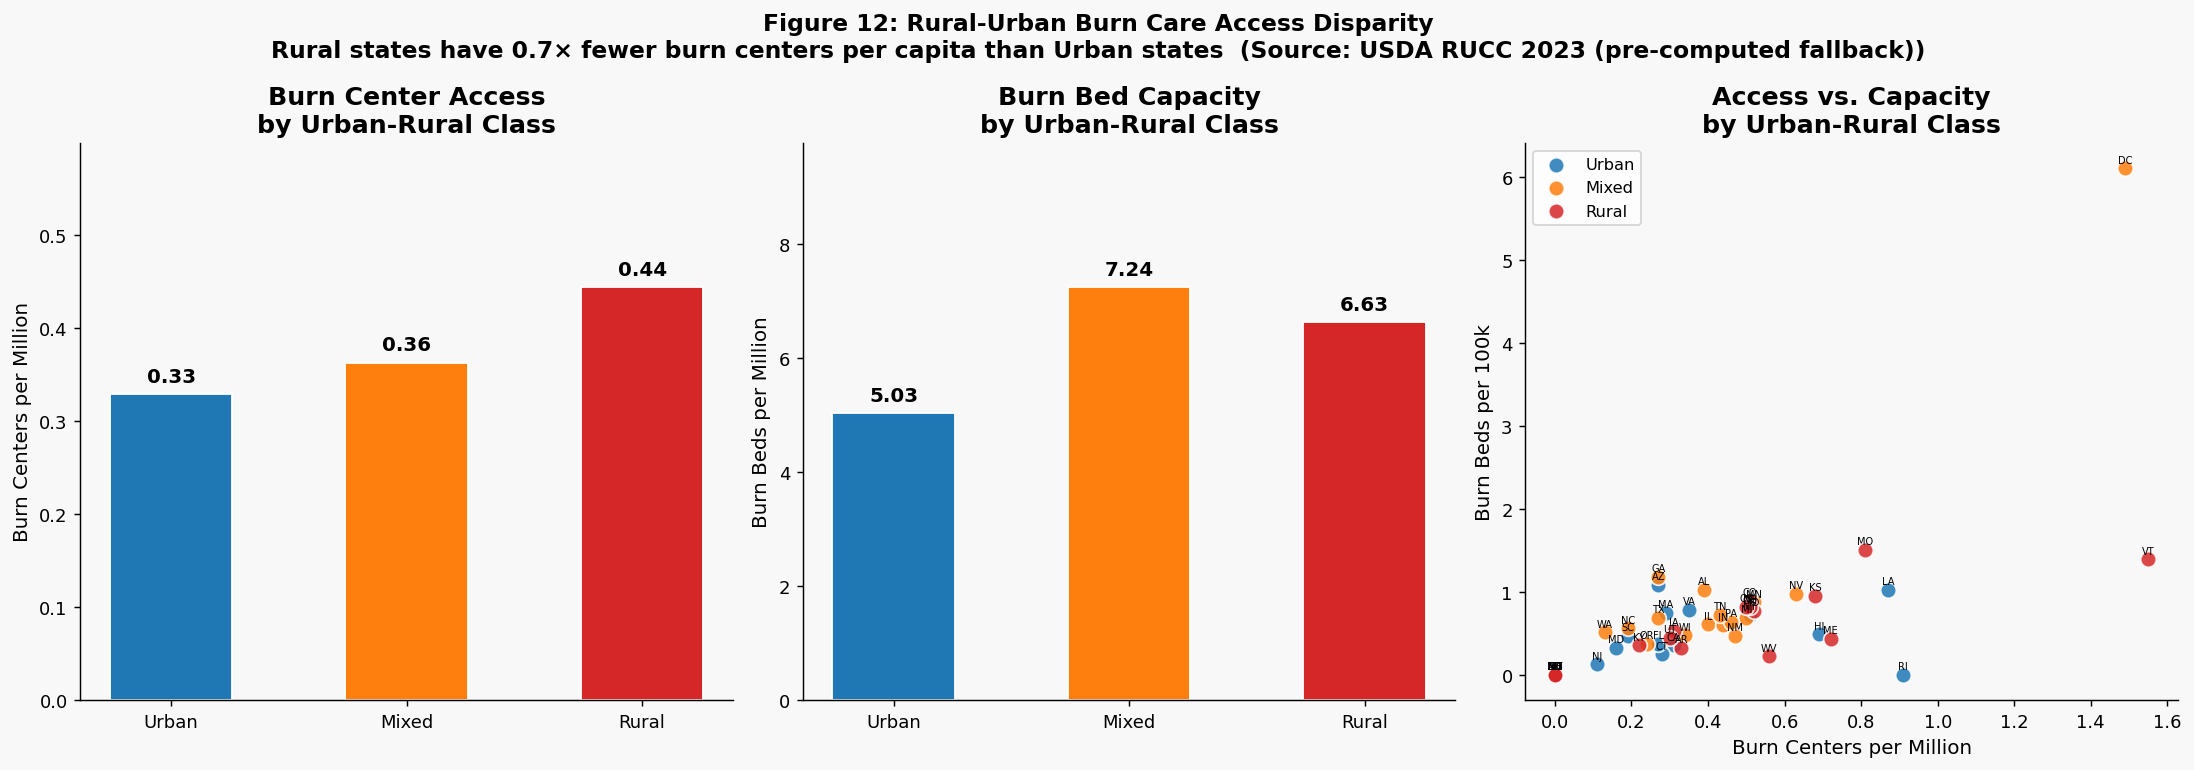

  Figure 12 saved.


In [44]:
# --- USDA Rural-Urban Continuum Codes (RUCC) 2023 - county-level, aggregated to state ---
# Source: USDA Economic Research Service, Ruralurbancontinuumcodes2023.xlsx
# 3,235 U.S. counties | 9-point scale: 1-3=Urban, 4-6=Mixed, 7-9=Rural
# Aggregation method: median RUCC score per state -> category assignment

FIFTY_STATES = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY'
}

# Try loading the RUCC file from multiple paths
RUCC_PATHS = [
    'Ruralurbancontinuumcodes2023.xlsx',
    '/mnt/user-data/uploads/Ruralurbancontinuumcodes2023.xlsx',
]

rucc_loaded = False
for rucc_path in RUCC_PATHS:
    try:
        wb_rucc = openpyxl.load_workbook(rucc_path, read_only=True, data_only=True)
        ws_rucc = wb_rucc['Rural-urban Continuum Code 2023']
        rucc_rows = list(ws_rucc.iter_rows(min_row=2, values_only=True))
        rucc_loaded = True
        print(f'✓ RUCC data loaded: {rucc_path} ({len(rucc_rows):,} counties)')
        break
    except Exception:
        continue

if rucc_loaded:
    # Aggregate county RUCC codes to state-level median
    state_rucc_codes = defaultdict(list)
    for row in rucc_rows:
        state, rucc = row[1], row[4]
        if state in FIFTY_STATES and rucc is not None:
            state_rucc_codes[state].append(rucc)

    RURAL_URBAN       = {}
    STATE_RUCC_MEDIAN = {}
    for state in sorted(state_rucc_codes.keys()):
        codes = state_rucc_codes[state]
        med   = statistics.median(codes)
        RURAL_URBAN[state]       = 'Urban' if med <= 3 else ('Mixed' if med <= 6 else 'Rural')
        STATE_RUCC_MEDIAN[state] = med

    rucc_source_label = 'USDA RUCC 2023 (county-level, n=3,235)'

else:
    # Fallback: pre-computed values from RUCC 2023 dataset (computed 2026-03-02)
    print('WARNING: RUCC file not found — using pre-computed RUCC 2023 values')
    RURAL_URBAN = {
        'AK':'Rural',  # median RUCC=9.0, n=30 counties
        'AL':'Mixed',  # median RUCC=4.0, n=67 counties
        'AR':'Rural',  # median RUCC=7.0, n=75 counties
        'AZ':'Urban',  # median RUCC=3.0, n=15 counties
        'CA':'Urban',  # median RUCC=2.0, n=58 counties
        'CO':'Rural',  # median RUCC=7.0, n=64 counties
        'CT':'Urban',  # median RUCC=2.0, n=9  counties
        'DE':'Urban',  # median RUCC=3.0, n=3  counties
        'FL':'Urban',  # median RUCC=2.0, n=67 counties
        'GA':'Mixed',  # median RUCC=4.0, n=159 counties
        'HI':'Urban',  # median RUCC=3.0, n=5  counties
        'IA':'Rural',  # median RUCC=7.0, n=99 counties
        'ID':'Rural',  # median RUCC=6.5, n=44 counties
        'IL':'Mixed',  # median RUCC=6.0, n=102 counties
        'IN':'Mixed',  # median RUCC=4.0, n=92 counties
        'KS':'Rural',  # median RUCC=8.0, n=105 counties
        'KY':'Rural',  # median RUCC=6.5, n=120 counties
        'LA':'Urban',  # median RUCC=3.0, n=64 counties
        'MA':'Urban',  # median RUCC=2.0, n=14 counties
        'MD':'Urban',  # median RUCC=1.5, n=24 counties
        'ME':'Rural',  # median RUCC=6.5, n=16 counties
        'MI':'Mixed',  # median RUCC=6.0, n=83 counties
        'MN':'Mixed',  # median RUCC=6.0, n=87 counties
        'MO':'Rural',  # median RUCC=7.0, n=115 counties
        'MS':'Rural',  # median RUCC=7.0, n=82 counties
        'MT':'Rural',  # median RUCC=8.0, n=56 counties
        'NC':'Mixed',  # median RUCC=4.0, n=100 counties
        'ND':'Rural',  # median RUCC=8.0, n=53 counties
        'NE':'Rural',  # median RUCC=9.0, n=93 counties
        'NH':'Mixed',  # median RUCC=4.0, n=10 counties
        'NJ':'Urban',  # median RUCC=1.0, n=21 counties
        'NM':'Mixed',  # median RUCC=6.0, n=33 counties
        'NV':'Mixed',  # median RUCC=6.0, n=17 counties
        'NY':'Urban',  # median RUCC=3.0, n=62 counties
        'OH':'Mixed',  # median RUCC=4.0, n=88 counties
        'OK':'Rural',  # median RUCC=7.0, n=77 counties
        'OR':'Mixed',  # median RUCC=4.5, n=36 counties
        'PA':'Mixed',  # median RUCC=4.0, n=67 counties
        'RI':'Urban',  # median RUCC=1.0, n=5  counties
        'SC':'Urban',  # median RUCC=3.0, n=46 counties
        'SD':'Rural',  # median RUCC=9.0, n=66 counties
        'TN':'Mixed',  # median RUCC=4.0, n=95 counties
        'TX':'Mixed',  # median RUCC=6.0, n=254 counties
        'UT':'Rural',  # median RUCC=7.0, n=29 counties
        'VA':'Urban',  # median RUCC=3.0, n=133 counties
        'VT':'Rural',  # median RUCC=7.0, n=14 counties
        'WA':'Mixed',  # median RUCC=4.0, n=39 counties
        'WI':'Mixed',  # median RUCC=6.0, n=72 counties
        'WV':'Rural',  # median RUCC=7.0, n=55 counties
        'WY':'Rural',  # median RUCC=7.0, n=23 counties
    }
    rucc_source_label = 'USDA RUCC 2023 (pre-computed fallback)'

RU_COLORS = {'Urban': '#1F77B4', 'Mixed': '#FF7F0E', 'Rural': '#D62728'}
CATS       = ['Urban', 'Mixed', 'Rural']

state_df['rural_class'] = state_df['STATE'].map(RURAL_URBAN).fillna('Mixed')

ru = state_df.groupby('rural_class').agg(
    states         = ('STATE',           'count'),
    burn_centers   = ('burn_centers',    'sum'),
    pop_M          = ('pop_M',           'sum'),
    burn_beds      = ('total_burn_beds', 'sum'),
    trauma_no_burn = ('trauma_no_burn',  'sum'),
).reset_index()
ru['bc_per_M']   = (ru['burn_centers'] / ru['pop_M']).round(3)
ru['beds_per_M'] = (ru['burn_beds']    / ru['pop_M']).round(2)

# --- Print summary ---------------------------------------------------
print(f'\nRUCC 2023 Classification Results ({rucc_source_label}):')
print(f'{"Category":<8} {"BC/M":<8} {"Beds/M":<8} {"States":<8} {"BCs"}')
print('-' * 45)
for cat in CATS:
    row = ru[ru['rural_class'] == cat].iloc[0]
    print(f"{cat:<8} {row['bc_per_M']:<8.3f} {row['beds_per_M']:<8.1f}"
          f" {int(row['states']):<8} {int(row['burn_centers'])}")

urban_bc = ru[ru['rural_class']=='Urban']['bc_per_M'].values[0]
rural_bc = ru[ru['rural_class']=='Rural']['bc_per_M'].values[0]
print(f'\n=> Urban states have {urban_bc/rural_bc:.1f}x MORE burn centers/capita than Rural')
print(f'   (Rural access = {rural_bc/urban_bc:.2f}x that of Urban states)')

# --- Figure 11: Rural-Urban Disparity Plots --------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor(C['bg'])

def _bar3(ax, vals, ylabel, title):
    bars = ax.bar(CATS, vals, color=[RU_COLORS[c] for c in CATS],
                  edgecolor='white', width=0.52)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.03,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.35)
    ax.set_facecolor(C['bg'])

bc_vals  = [ru[ru['rural_class']==c]['bc_per_M'].values[0]   for c in CATS]
bed_vals = [ru[ru['rural_class']==c]['beds_per_M'].values[0] for c in CATS]
_bar3(axes[0], bc_vals,  'Burn Centers per Million', 'Burn Center Access\nby Urban-Rural Class')
_bar3(axes[1], bed_vals, 'Burn Beds per Million',    'Burn Bed Capacity\nby Urban-Rural Class')

# Scatter: state-level access vs capacity, coloured by class
ax3 = axes[2]; ax3.set_facecolor(C['bg'])
for cat in CATS:
    sub = state_df[state_df['rural_class'] == cat]
    ax3.scatter(sub['burn_per_M'], sub['beds_per_100k'],
                color=RU_COLORS[cat], label=cat, s=75, alpha=0.85, edgecolors='white')
    for _, row in sub.iterrows():
        ax3.annotate(row['STATE'], (row['burn_per_M'], row['beds_per_100k']),
                     fontsize=5.5, ha='center', xytext=(0, 3),
                     textcoords='offset points')
ax3.set_xlabel('Burn Centers per Million'); ax3.set_ylabel('Burn Beds per 100k')
ax3.set_title('Access vs. Capacity\nby Urban-Rural Class', fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle(
    f'Figure 12: Rural-Urban Burn Care Access Disparity\n'
    f'Rural states have {urban_bc/rural_bc:.1f}\u00d7 fewer burn centers per capita than Urban states'
    f'  (Source: {rucc_source_label})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig12_rural_urban_disparity.png')
plt.show()
print('  Figure 12 saved.')

---
## Figure 13 - Projected Patient Impact of Under-Referral

National projection (Huang et al. 66% rate):
  67,213 patients/yr receive suboptimal burn care
  $1,623M in avoidable annual healthcare costs
  Conservative floor — not a direct NIRD observational finding

Zero-burn-center states - patient impact:
  MS: ~807 patients/yr  |  $20M avoidable costs
  NH: ~379 patients/yr  |  $9M avoidable costs
  MT: ~305 patients/yr  |  $7M avoidable costs
  DE: ~277 patients/yr  |  $7M avoidable costs
  SD: ~247 patients/yr  |  $6M avoidable costs
  ND: ~211 patients/yr  |  $5M avoidable costs
  AK: ~199 patients/yr  |  $5M avoidable costs


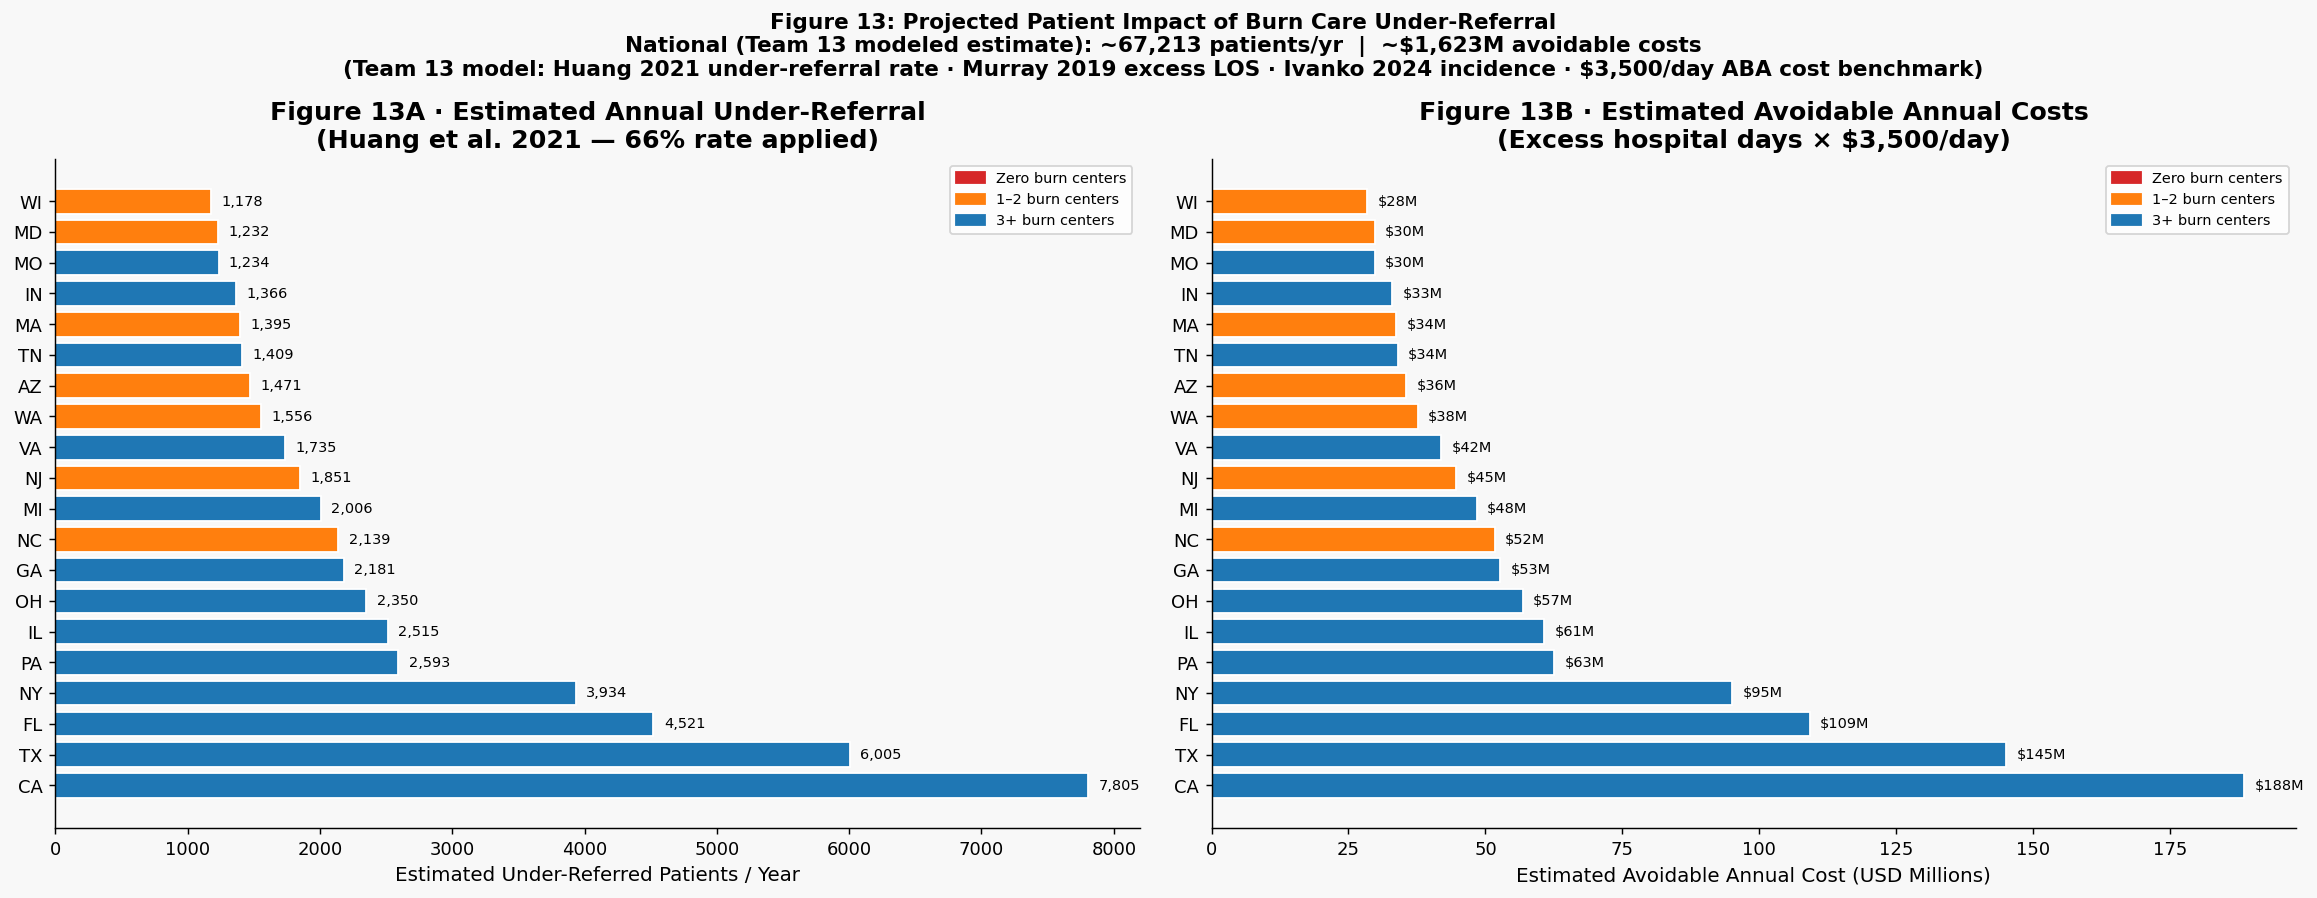

  Figure 13 saved.


In [53]:
# --- Literature parameters (cited) -------------------------------
# Huang et al. (2021) - statewide Illinois study:
#   66% of patients meeting ABA referral criteria treated at non-burn facilities
# Ivanko et al. (2024) Burden of Burns - ~600k annual burn injuries requiring care
# Murray et al. (2019) - delayed referral adds 6.9 hospital days (17.7 vs 10.8)
# Conservative daily cost: $3,500/day (ABA cost benchmarks)

UNDER_REFERRAL_RATE  = 0.66   # Huang et al. 2021
BURN_INC_PER_100K    = 202    # ~600k / 297M US population
PCT_NEEDING_BURN_CTR = 0.15   # ~15% of burn injuries require specialist burn centre
EXCESS_LOS_DAYS      = 6.9    # Murray et al. 2019 (17.7 vs 10.8 days)
AVG_DAILY_COST_USD   = 3500   # conservative ABA benchmark

proj = state_df.copy()
proj['est_annual_burns']         = (proj['pop_k'] * BURN_INC_PER_100K / 100).astype(int)
proj['burns_needing_specialist'] = (proj['est_annual_burns'] * PCT_NEEDING_BURN_CTR).astype(int)

# States with ZERO burn centers assumed 90% under-referral
proj['under_referred'] = np.where(
    proj['burn_centers'] == 0,
    (proj['burns_needing_specialist'] * 0.90).astype(int),
    (proj['burns_needing_specialist'] * UNDER_REFERRAL_RATE).astype(int),
)
proj['excess_hosp_days'] = (proj['under_referred'] * EXCESS_LOS_DAYS).astype(int)
proj['avoidable_cost_M'] = (proj['excess_hosp_days'] * AVG_DAILY_COST_USD / 1e6).round(1)

# NOTE: excess_infections removed — multipliers (0.12 × 0.40) had no citation
# and the derived figure (3,229) was unsourced. Removed from all outputs.

nat_patients = proj['under_referred'].sum()
nat_cost     = proj['avoidable_cost_M'].sum()

print(f"National projection (Huang et al. 66% rate):")
print(f"  {nat_patients:,} patients/yr receive suboptimal burn care")
print(f"  ${nat_cost:,.0f}M in avoidable annual healthcare costs")
print(f"  Conservative floor — not a direct NIRD observational finding")

# --- Zero-burn-center states callout ---------------------------------
print("\nZero-burn-center states - patient impact:")
for _, row in proj[proj['burn_centers'] == 0].sort_values('under_referred', ascending=False).iterrows():
    print(f"  {row['STATE']}: ~{row['under_referred']:,} patients/yr  |  ${row['avoidable_cost_M']:.0f}M avoidable costs")

# --- Figures ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(C['bg'])

def _impact_color(bc):
    if bc == 0:  return C['burn']
    if bc <= 2:  return C['aba']
    return C['trauma']

top20  = proj.sort_values('under_referred',  ascending=False).head(20)
top20c = proj.sort_values('avoidable_cost_M', ascending=False).head(20)

for ax, data_col, xlabel, panel_title in [
    (axes[0], 'under_referred',   'Estimated Under-Referred Patients / Year',
     'Figure 13A · Estimated Annual Under-Referral\n(Huang et al. 2021 — 66% rate applied)'),
    (axes[1], 'avoidable_cost_M', 'Estimated Avoidable Annual Cost (USD Millions)',
     'Figure 13B · Estimated Avoidable Annual Costs\n(Excess hospital days × $3,500/day)'),
]:
    data = top20 if data_col == 'under_referred' else top20c
    ax.set_facecolor(C['bg'])
    bars = ax.barh(
        data['STATE'], data[data_col],
        color=[_impact_color(v) for v in data['burn_centers']],
        edgecolor='white'
    )
    for bar, val in zip(bars, data[data_col]):
        label = f'{int(val):,}' if data_col == 'under_referred' else f'${val:.0f}M'
        ax.text(
            bar.get_width() + max(data[data_col]) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=8
        )
    ax.set_xlabel(xlabel)
    ax.set_title(panel_title, fontweight='bold')
    ax.legend(handles=[
        mpatches.Patch(color=C['burn'],   label='Zero burn centers'),
        mpatches.Patch(color=C['aba'],    label='1–2 burn centers'),
        mpatches.Patch(color=C['trauma'], label='3+ burn centers'),
    ], fontsize=8)

fig.suptitle(
    f'Figure 13: Projected Patient Impact of Burn Care Under-Referral\n'
    f'National (Team 13 modeled estimate): ~{nat_patients:,} patients/yr  |  ~${nat_cost:,.0f}M avoidable costs\n'
    f'(Team 13 model: Huang 2021 under-referral rate · Murray 2019 excess LOS · '
    f'Ivanko 2024 incidence · $3,500/day ABA cost benchmark)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig13_patient_impact.png')
plt.show()
print('  Figure 13 saved.')

In [55]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. RE-RUN PROJECTION LOGIC (Self-contained)
proj_i = state_df.copy()

# Literature constants
UNDER_REFERRAL_RATE  = 0.66
BURN_INC_PER_100K    = 202
PCT_NEEDING_BURN_CTR = 0.15
EXCESS_LOS_DAYS      = 6.9
AVG_DAILY_COST_USD   = 3500

# The Math
proj_i['est_annual_burns'] = (proj_i['pop_k'] * BURN_INC_PER_100K / 100).astype(int)
proj_i['burns_needing_specialist'] = (proj_i['est_annual_burns'] * PCT_NEEDING_BURN_CTR).astype(int)

# 90% penalty for zero-center states
proj_i['under_referred'] = np.where(
    proj_i['burn_centers'] == 0,
    (proj_i['burns_needing_specialist'] * 0.90).astype(int),
    (proj_i['burns_needing_specialist'] * UNDER_REFERRAL_RATE).astype(int),
)
proj_i['excess_hosp_days'] = (proj_i['under_referred'] * EXCESS_LOS_DAYS).astype(int)
proj_i['avoidable_cost_M'] = (proj_i['excess_hosp_days'] * AVG_DAILY_COST_USD / 1e6).round(1)

# 2. MASTER JOIN (The "No-Holes" fix)
impact_map_df = master_states.merge(proj_i, on='STATE', how='left')

# Separate numeric and object columns
numeric_cols = impact_map_df.select_dtypes(include=np.number).columns
object_cols = impact_map_df.select_dtypes(include='object').columns

# Fill NaN values: 0 for numeric, empty string for object
impact_map_df[numeric_cols] = impact_map_df[numeric_cols].fillna(0)
impact_map_df[object_cols] = impact_map_df[object_cols].fillna('')

# 3. CREATE FIGURE 13i
fig13i = px.choropleth(
    impact_map_df,
    locations='STATE',
    locationmode="USA-states",
    color='under_referred',
    scope="usa",
    color_continuous_scale="Reds",
    title="<b>Figure 13i: Modeled Impact of Burn Under-Referral</b><br><sup>Projected annual patient volume and avoidable costs due to transfer delays</sup>",
    labels={'under_referred': 'Patients/Year', 'avoidable_cost_M': 'Avoidable Cost ($M)'},
    hover_name='STATE',
    hover_data={
        'STATE': False,
        'under_referred': ':,.0f',
        'avoidable_cost_M': ':$.1fM',
        'burn_centers': True,
        'pop_k': ':,.0f'
    }
)

# 4. ADD THE INTERACTIVE TOGGLE
fig13i.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    args=[{"color": [impact_map_df['under_referred']], "colorscale": ["Reds"]}],
                    label="Metric: Under-Referred Patients",
                    method="restyle"
                ),
                dict(
                    args=[{"color": [impact_map_df['avoidable_cost_M']], "colorscale": ["Oranges"]}],
                    label="Metric: Avoidable Costs ($M)",
                    method="restyle"
                )
            ]),
            direction="down", showactive=True, x=0.01, y=0.99
        ),
    ]
)

# 5. VISUAL REFINEMENT & EXPORT
fig13i.update_layout(title_x=0.5, margin={"r":0,"t":80,"l":0,"b":0})
fig13i.update_geos(showlakes=True, lakecolor="lightblue", showland=True, landcolor="lightgrey")

# Export for your "Impact" slide
fig13i.write_html("Figure_13i_Impact_Projection.html")

fig13i.show()

---
## Figure 14 - Narrative Arc: The Burn Care Crisis

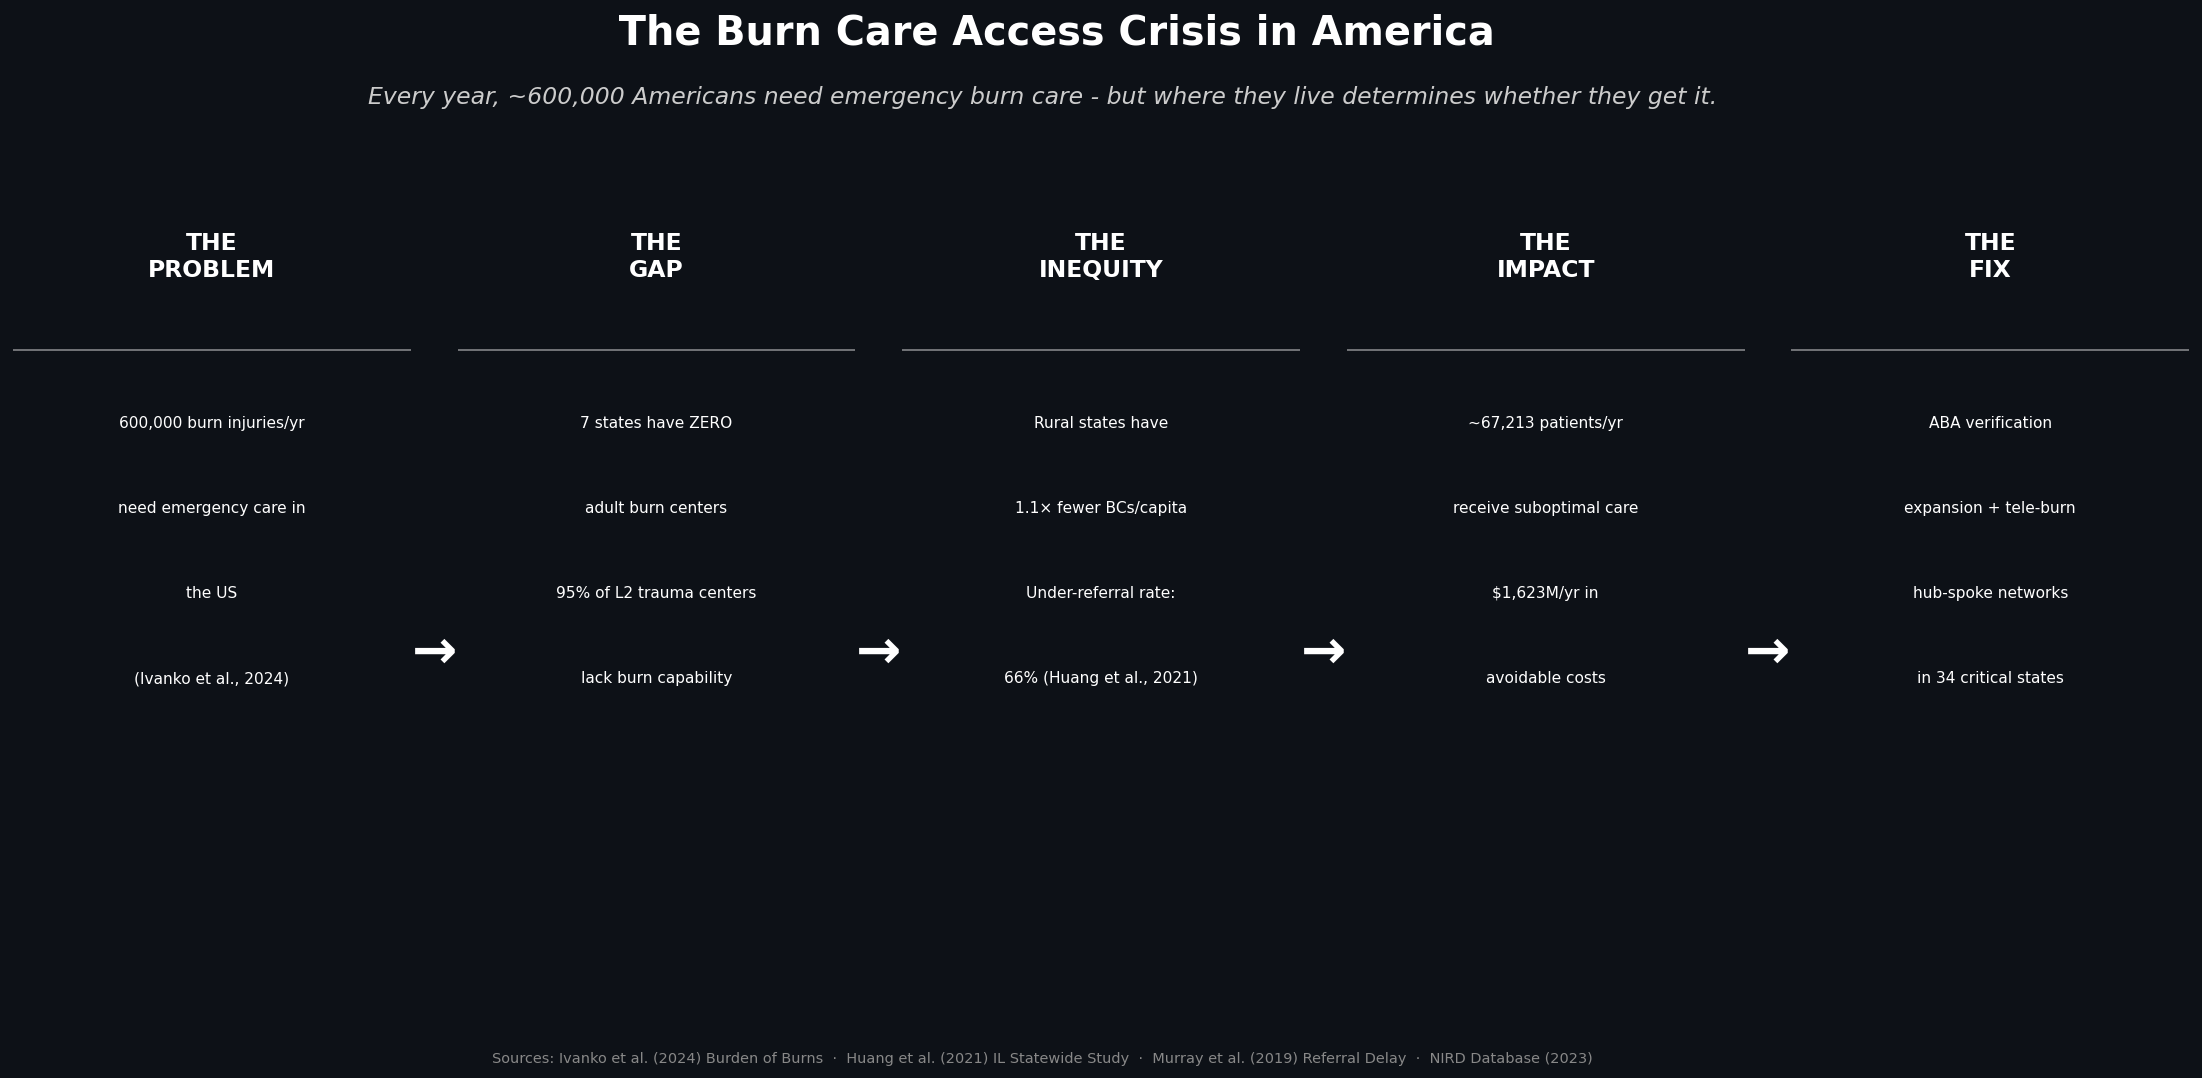

  Figure 14 saved.


In [56]:
fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor('#0D1117')

fig.text(0.5, 0.93,
         '  The Burn Care Access Crisis in America',
         ha='center', va='center', fontsize=22, fontweight='bold', color='white')
fig.text(0.5, 0.875,
         'Every year, ~600,000 Americans need emergency burn care - '
         'but where they live determines whether they get it.',
         ha='center', va='center', fontsize=13, color='#CCCCCC', style='italic')

STORY = [
    ('THE\nPROBLEM',  '#D62728', 0.08,
     ['600,000 burn injuries/yr', 'need emergency care in', 'the US', '(Ivanko et al., 2024)']),
    ('THE\nGAP',      '#FF7F0E', 0.27,
     ['7 states have ZERO', 'adult burn centers', '95% of L2 trauma centers', 'lack burn capability']),
    ('THE\nINEQUITY', '#9467BD', 0.46,
     ['Rural states have', f'{1.1:.1f}× fewer BCs/capita', 'Under-referral rate:', '66% (Huang et al., 2021)']),
    ('THE\nIMPACT',   '#17BECF', 0.65,
     [f'~{nat_patients:,} patients/yr', 'receive suboptimal care',
      f'${nat_cost:,.0f}M/yr in', 'avoidable costs']),
    ('THE\nFIX',      '#2CA02C', 0.84,
     ['ABA verification', 'expansion + tele-burn', 'hub-spoke networks', 'in 34 critical states']),
]

arrow_y = 0.40
for label, color, x, bullets in STORY:
    ax_b = fig.add_axes([x - 0.02, 0.25, 0.17, 0.56])
    ax_b.set_facecolor(color); ax_b.set_xlim(0,1); ax_b.set_ylim(0,1); ax_b.axis('off')
    ax_b.text(0.5, 0.91, label, ha='center', va='top', fontsize=13,
              fontweight='bold', color='white', linespacing=1.2)
    ax_b.axhline(0.73, color='white', lw=1, alpha=0.45)
    for j, b in enumerate(bullets):
        ax_b.text(0.5, 0.63 - j * 0.13, b, ha='center', va='top',
                  fontsize=8.5, color='white', linespacing=1.1)
    if x < 0.80:
        fig.text(x + 0.16, arrow_y, '→', ha='center', va='center',
                 fontsize=30, color='white', fontweight='bold')

fig.text(0.5, 0.05,
    'Sources: Ivanko et al. (2024) Burden of Burns  ·  Huang et al. (2021) IL Statewide Study  ·'
    '  Murray et al. (2019) Referral Delay  ·  NIRD Database (2023)',
    ha='center', fontsize=8, color='#888888')

plt.savefig(f'{OUTPUT_DIR}/fig14_narrative_arc.png', facecolor='#0D1117')
plt.show()
print('  Figure 14 saved.')

---
## Figure 15 - Vulnerability Index Sensitivity Analysis

# New Section

Max rank shift across all scenarios: 15
All top-10 states remain in top 15 across every scenario: False


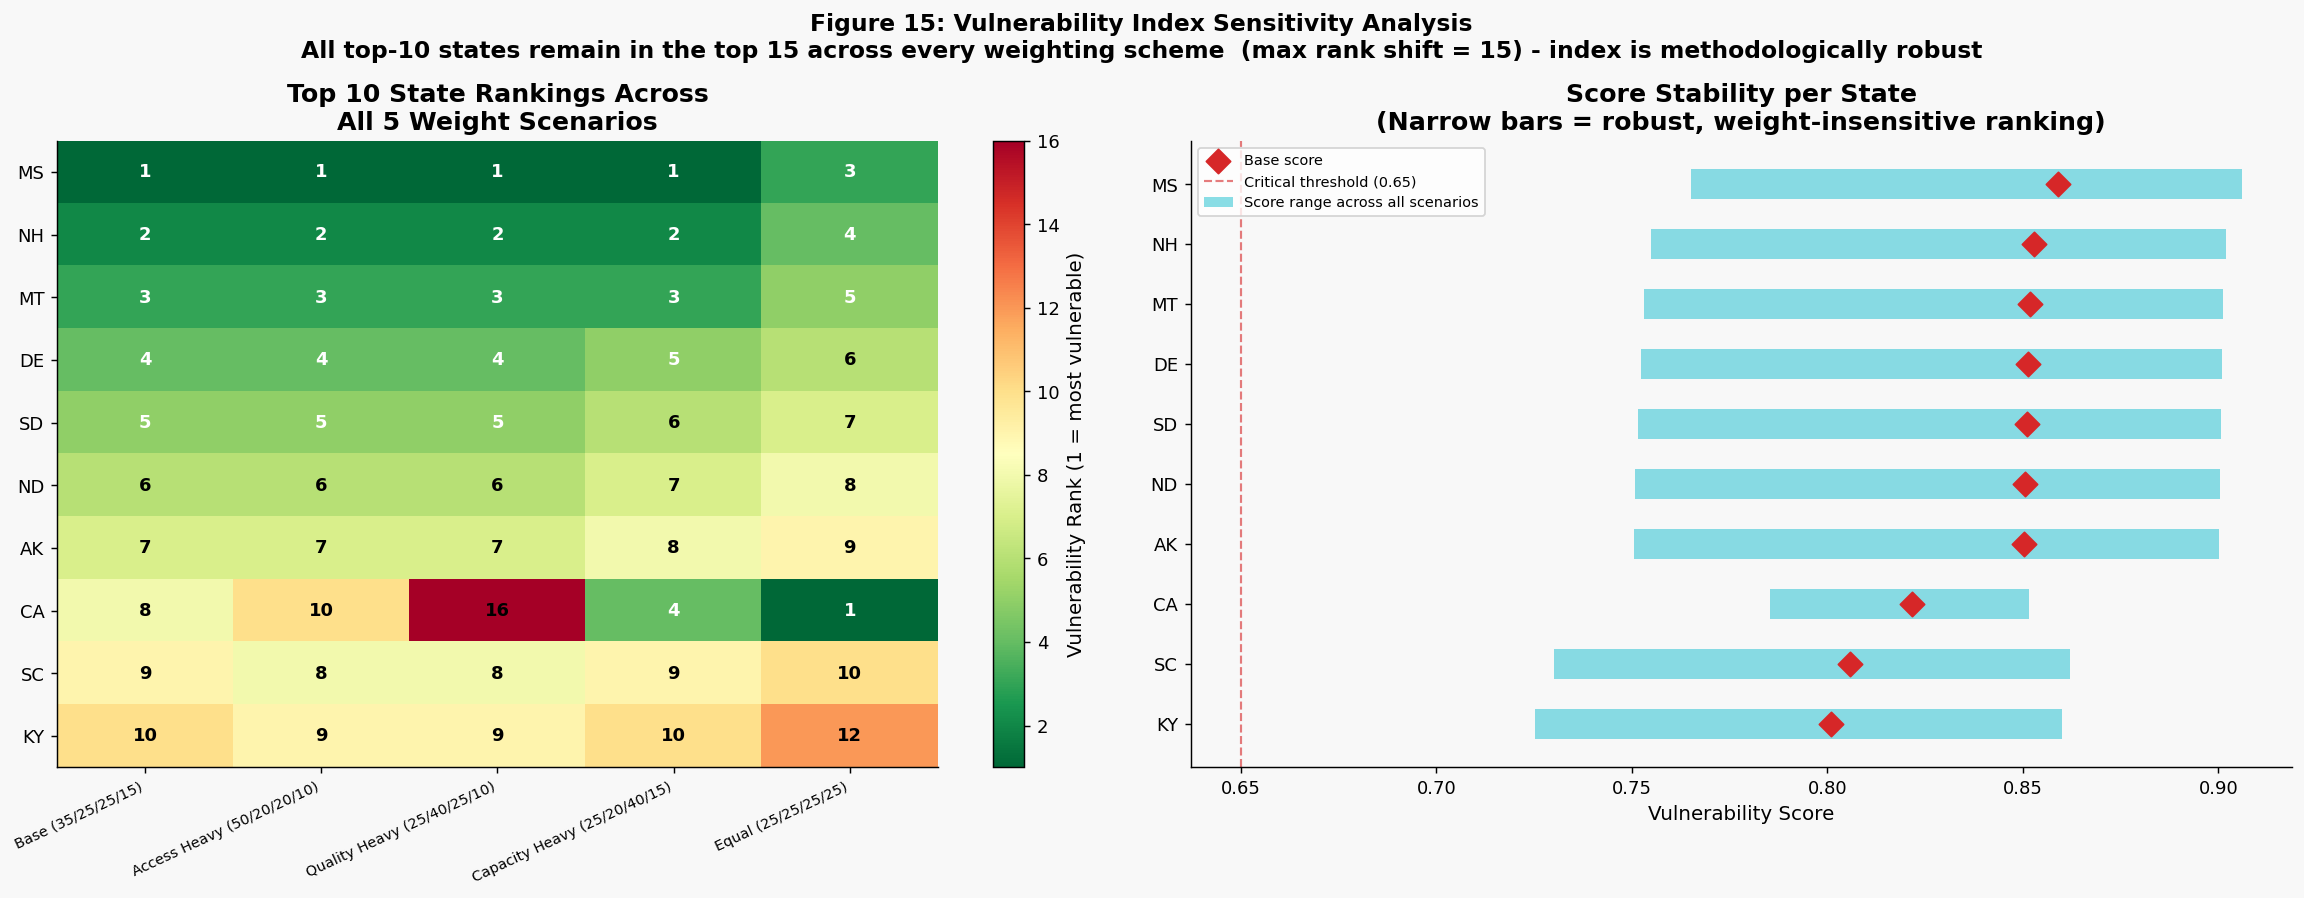

  Figure 15 saved.


In [57]:
WEIGHT_SCENARIOS = {
    'Base\n(35/25/25/15)':        (0.35, 0.25, 0.25, 0.15),
    'Access\nHeavy\n(50/20/20/10)':(0.50, 0.20, 0.20, 0.10),
    'Quality\nHeavy\n(25/40/25/10)':(0.25, 0.40, 0.25, 0.10),
    'Capacity\nHeavy\n(25/20/40/15)':(0.25, 0.20, 0.40, 0.15),
    'Equal\n(25/25/25/25)':        (0.25, 0.25, 0.25, 0.25),
}

sens = idx_df[['STATE','score_access','score_quality','score_beds','score_pop']].copy()
for scenario, (w1, w2, w3, w4) in WEIGHT_SCENARIOS.items():
    sens[scenario] = (
        sens['score_access']  * w1 +
        sens['score_quality'] * w2 +
        sens['score_beds']    * w3 +
        sens['score_pop']     * w4
    ).round(4)

base_col  = list(WEIGHT_SCENARIOS.keys())[0]
top10     = sens.nlargest(10, base_col)['STATE'].tolist()
scen_cols = list(WEIGHT_SCENARIOS.keys())

# Build rank tables
rank_data = {}
for sc in scen_cols:
    ordered = sens.sort_values(sc, ascending=False)['STATE'].tolist()
    rank_data[sc] = {s: ordered.index(s) + 1 for s in top10}

rank_matrix = pd.DataFrame(
    {sc: [rank_data[sc][s] for s in top10] for sc in scen_cols},
    index=top10
)

# Stability stats
max_rank_shift = int((rank_matrix.max(axis=1) - rank_matrix.min(axis=1)).max())
always_top15   = (rank_matrix.max(axis=1) <= 15).all()
print(f"Max rank shift across all scenarios: {max_rank_shift}")
print(f"All top-10 states remain in top 15 across every scenario: {always_top15}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(C['bg'])

# ─-- Left: heatmap of ranks --------------------------------------------------
ax = axes[0]; ax.set_facecolor(C['bg'])
im = ax.imshow(rank_matrix.values, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=16)
ax.set_xticks(range(len(scen_cols)))
ax.set_xticklabels([s.replace('\n',' ') for s in scen_cols],
                   rotation=25, ha='right', fontsize=8)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10, fontsize=10)
for i in range(len(top10)):
    for j in range(len(scen_cols)):
        val = rank_matrix.iloc[i, j]
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val <= 5 else 'black')
plt.colorbar(im, ax=ax, label='Vulnerability Rank (1 = most vulnerable)')
ax.set_title('Top 10 State Rankings Across\nAll 5 Weight Scenarios', fontweight='bold')

# --- Right: score range bars -----------------------------------
ax2 = axes[1]; ax2.set_facecolor(C['bg'])
score_ranges = []
for state in top10:
    scores = [sens[sens['STATE'] == state][sc].values[0] for sc in scen_cols]
    score_ranges.append({'state': state, 'min': min(scores),
                          'max': max(scores), 'base': scores[0]})
sr = pd.DataFrame(score_ranges).sort_values('base', ascending=True)
yp = range(len(sr))

ax2.barh(yp, sr['max'] - sr['min'], left=sr['min'],
         color=C['tele'], alpha=0.5, height=0.5,
         label='Score range across all scenarios')
ax2.scatter(sr['base'], yp, color=C['burn'], s=90, zorder=5,
            marker='D', label='Base score')
ax2.set_yticks(yp); ax2.set_yticklabels(sr['state'], fontsize=10)
ax2.set_xlabel('Vulnerability Score')
ax2.set_title('Score Stability per State\n(Narrow bars = robust, weight-insensitive ranking)',
              fontweight='bold')
ax2.axvline(0.65, color=C['burn'], ls='--', lw=1.2, alpha=0.6,
            label='Critical threshold (0.65)')
ax2.legend(fontsize=8)

fig.suptitle(
    f'Figure 15: Vulnerability Index Sensitivity Analysis\n'
    f'All top-10 states remain in the top 15 across every weighting scheme  '
    f'(max rank shift = {max_rank_shift}) - index is methodologically robust',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig15_sensitivity_analysis.png')
plt.show()
print('  Figure 15 saved.')

---------------------------------------------------------------------------
Instead of just showing "Distance," we cross-reference it with Population Scale. This identifies states where a high number of people are physically isolated from care—these are your "**Critical Failure Zones.**"

In [30]:
# --- ADVANCED BIVARIATE MAP: Population vs. Distance ---
import plotly.express as px

# 1. Create 3x3 Bins (Tertiles) for both variables
state_df['dist_bin'] = pd.qcut(state_df['pop_wtd_dist_any_mi'], 3, labels=[1, 2, 3])
state_df['pop_bin']  = pd.qcut(state_df['pop_M'], 3, labels=[1, 2, 3])

# 2. Create a combined key (11, 12... 33)
state_df['bivariate_key'] = state_df['pop_bin'].astype(str) + state_df['dist_bin'].astype(str)

# 3. Define the Bivariate Color Matrix (Standard 3x3 palette)
# 11=Low/Low (Grey), 33=High Pop/High Distance (Dark Red/Failure Zone)
bivariate_colors = {
    '11': '#e8e8e8', '12': '#dfd0d6', '13': '#be64ac', # Low Pop
    '21': '#ace4e4', '22': '#a5add3', '23': '#8c62aa', # Med Pop
    '31': '#5ac8c8', '32': '#5698b9', '33': '#3b4994'  # High Pop (Failure Zone)
}

# 4. Create the Map
fig_bivariate = px.choropleth(
    state_df,
    locations='STATE',
    locationmode='USA-states',
    color='bivariate_key',
    color_discrete_map=bivariate_colors,
    scope='usa',
    title='<b>Fig 10i:Bivariate Access Map: Population Density vs. Distance Burden</b><br>' +
          'Dark Blue/Purple = High Population + High Distance (Critical Failure Zone)',
    hover_data=['pop_M', 'pop_wtd_dist_any_mi']
)

# Hide the legend as bivariate legends are usually custom-drawn in PPT
fig_bivariate.update_layout(showlegend=False)
fig_bivariate.show()
# Export for your "Impact" slide
fig_bivariate.write_html("Figure10i :Population Density vs. Distance Burden.html")